<a href="https://colab.research.google.com/github/tivanello/fase2/blob/main/notebook/Prova_Substitutiva_DTAT_FASE2_maio_2026_Eduardo_Gil_Tivanello.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importação dos arquivos**

Foi realizada a importação da série histórica a partir de **01/01/2023** até **13/05/2026**  


In [185]:
#####################################################################
# BLOCO 1 — IMPORTAÇÃO E CONSOLIDAÇÃO DOS DADOS
#####################################################################

# Importa biblioteca
import pandas as pd

# URL da base histórica do IBOVESPA (01.01.2023 - 13.05.2026)
url = "https://raw.githubusercontent.com/tivanello/fase2/refs/heads/main/data/raw/Dados%20Hist%C3%B3ricos%20-%20Ibovespa%20-%20Substitutiva.csv"

# Leitura do arquivo CSV
# A coluna Data é forçada como string para evitar interpretação incorreta pelo pandas
df = pd.read_csv(url, thousands='.', decimal=',', dtype={'Data': str})

df_ibovespa = df.copy()

# Visualizações iniciais
print("Primeiras linhas:")
print(df_ibovespa.head())

print("\nDimensão da base:")
print(df_ibovespa.shape)

print("\nInformações gerais:")
print(df_ibovespa.info())




Primeiras linhas:
         Data  Último  Abertura  Máxima  Mínima    Vol.    Var%
0  13.05.2026  177098    180342  180513  176787  12,62B  -1,80%
1  12.05.2026  180342    181897  181897  179939   9,06B  -0,86%
2  11.05.2026  181909    184103  184530  181615   8,78B  -1,19%
3  08.05.2026  184108    183222  185584  183217   9,21B   0,49%
4  07.05.2026  183218    187690  187779  182868   9,64B  -2,38%

Dimensão da base:
(838, 7)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Data      838 non-null    object
 1   Último    838 non-null    int64 
 2   Abertura  838 non-null    int64 
 3   Máxima    838 non-null    int64 
 4   Mínima    838 non-null    int64 
 5   Vol.      838 non-null    object
 6   Var%      838 non-null    object
dtypes: int64(4), object(3)
memory usage: 46.0+ KB
None


### **BLOCO 1 — Importação e consolidação dos dados**


Neste bloco foi realizada a importação inicial da base histórica do IBOVESPA, obtida a partir do repositório do projeto no GitHub.

A leitura do arquivo CSV foi feita com tratamento dos separadores numéricos no padrão brasileiro, utilizando ponto como separador de milhar e vírgula como separador decimal.

A coluna **Data** foi carregada inicialmente como texto para evitar interpretações automáticas incorretas pelo pandas. Em seguida, a base foi armazenada no dataframe **df_ibovespa**, que será utilizado nas próximas etapas do projeto.

A base carregada possui **838 registros** e **7 colunas**, contendo informações diárias do IBOVESPA no período analisado. Após a ordenação temporal, o primeiro pregão disponível na base é **02/01/2023** e o último é **13/05/2026**.

A visualização inicial mostrou que as colunas **Último**, **Abertura**, **Máxima** e **Mínima** já foram interpretadas como valores numéricos inteiros. As colunas **Data**, **Vol.** e **Var%** permanecem como texto e serão tratadas nas próximas etapas.

In [186]:
#####################################################################
# BLOCO 2 — PADRONIZAÇÃO DOS NOMES DAS COLUNAS
#####################################################################

df_ibovespa = df_ibovespa.rename(
    columns={
        'Data': 'data',
        'Último': 'fechamento',
        'Abertura': 'abertura',
        'Máxima': 'maxima',
        'Mínima': 'minima',
        'Vol.': 'volume',
        'Var%': 'variacao'
    }
)

# Visualização inicial
df_ibovespa.head()

,data,fechamento,abertura,maxima,minima,volume,variacao
0,13.05.2026,177098,180342,180513,176787,"12,62B","-1,80%"
1,12.05.2026,180342,181897,181897,179939,"9,06B","-0,86%"
2,11.05.2026,181909,184103,184530,181615,"8,78B","-1,19%"
3,08.05.2026,184108,183222,185584,183217,"9,21B","0,49%"
4,07.05.2026,183218,187690,187779,182868,"9,64B","-2,38%"


### **BLOCO 2 — Padronização dos nomes das colunas**

Neste bloco, os nomes das colunas foram padronizados para facilitar o uso no Python.

Foram removidos acentos, espaços e símbolos, substituindo os nomes originais por versões mais simples e descritivas, como **fechamento**, **abertura**, **maxima**, **minima**, **volume** e **variacao**.

Essa etapa reduz o risco de erros no código e melhora a organização das próximas fases de tratamento, análise e modelagem.

In [187]:
#####################################################################
# BLOCO 3 — TRATAMENTO DA COLUNA DE DATA E ORDENAÇÃO TEMPORAL
#####################################################################

# Converte a coluna de data para datetime (formato brasileiro)
df_ibovespa['data'] = pd.to_datetime(df_ibovespa['data'], dayfirst=True)

# Ordena cronologicamente (ESSENCIAL para séries temporais)
df_ibovespa = df_ibovespa.sort_values(by='data').reset_index(drop=True)

# Verificação
print(df_ibovespa.head())
print("Data inicial:", df_ibovespa['data'].min())
print("Data final:", df_ibovespa['data'].max())


        data  fechamento  abertura  maxima  minima  volume variacao
0 2023-01-02      106376    109734  109734  105981   8,13M   -3,06%
1 2023-01-03      104166    106377  106684  103852  14,47M   -2,08%
2 2023-01-04      105334    104167  105627  103915  14,45M    1,12%
3 2023-01-05      107641    105336  107743  105333  15,51M    2,19%
4 2023-01-06      108964    107642  109433  107642  12,63M    1,23%
Data inicial: 2023-01-02 00:00:00
Data final: 2026-05-13 00:00:00


### **Bloco 3 — Tratamento da coluna de data e ordenação temporal**
Neste bloco, a coluna **data** foi convertida para o formato datetime, considerando o padrão brasileiro de datas.

Em seguida, a base foi ordenada cronologicamente, do registro mais antigo para o mais recente. Essa etapa é fundamental em séries temporais, pois garante que as análises, os cálculos de defasagens e a modelagem respeitem a ordem real dos acontecimentos.

In [188]:
#####################################################################
# BLOCO 4 — CONVERSÃO DA VARIAÇÃO PERCENTUAL PARA NUMÉRICO
#####################################################################

df_ibovespa["variacao_num"] = (
    df_ibovespa["variacao"].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors='coerce') / 100.0
)

# Verificação
df_ibovespa[["variacao", "variacao_num"]].head()




,variacao,variacao_num
0,"-3,06%",-0.0306
1,"-2,08%",-0.0208
2,"1,12%",0.0112
3,"2,19%",0.0219
4,"1,23%",0.0123


###  **Conversão da variação percentual para formato numérico**
Neste bloco, a coluna **variacao**, originalmente em formato textual e percentual, foi convertida para uma nova coluna numérica chamada **variacao_num**.

O símbolo de percentual foi removido, a vírgula decimal foi substituída por ponto e os valores foram divididos por 100, permitindo o uso da variável em análises estatísticas e modelos preditivos.

In [189]:
#####################################################################
# BLOCO 5 — CONVERSÃO DO VOLUME PARA FORMATO NUMÉRICO
#####################################################################

import numpy as np

vol = df_ibovespa['volume'].astype(str)

# Ajusta separador decimal
vol = vol.str.replace(',', '.', regex=False)

# Inicializa coluna numérica
volume_num = pd.Series(index=vol.index, dtype='float64')

# Bilhões
mask_b = vol.str.endswith('B')
volume_num.loc[mask_b] = pd.to_numeric(
    vol.loc[mask_b].str.replace('B', '', regex=False),
    errors='coerce'
) * 1_000_000_000

# Milhões
mask_m = vol.str.endswith('M')
volume_num.loc[mask_m] = pd.to_numeric(
    vol.loc[mask_m].str.replace('M', '', regex=False),
    errors='coerce'
) * 1_000_000

# Milhares
mask_k = vol.str.endswith('K')
volume_num.loc[mask_k] = pd.to_numeric(
    vol.loc[mask_k].str.replace('K', '', regex=False),
    errors='coerce'
) * 1_000

# Substitui no DataFrame
df_ibovespa['volume_num'] = volume_num

# Verificação
df_ibovespa[['volume', 'volume_num']].head()

,volume,volume_num
0,"8,13M",8130000.0
1,"14,47M",14470000.0
2,"14,45M",14450000.0
3,"15,51M",15510000.0
4,"12,63M",12630000.0


### **Bloco 5 — Conversão da coluna de volume para formato numérico**
Neste bloco, a coluna **volume** foi convertida para uma nova coluna numérica chamada **volume_num**.

Os valores originalmente estavam em formato textual, com sufixos como **B** para bilhões, **M** para milhões e **K** para milhares. A conversão permite que o volume negociado seja utilizado em análises estatísticas, gráficos e modelos preditivos.

In [190]:
df_ibovespa.head()

,data,fechamento,abertura,maxima,minima,volume,variacao,variacao_num,volume_num
0,2023-01-02,106376,109734,109734,105981,"8,13M","-3,06%",-0.0306,8130000.0
1,2023-01-03,104166,106377,106684,103852,"14,47M","-2,08%",-0.0208,14470000.0
2,2023-01-04,105334,104167,105627,103915,"14,45M","1,12%",0.0112,14450000.0
3,2023-01-05,107641,105336,107743,105333,"15,51M","2,19%",0.0219,15510000.0
4,2023-01-06,108964,107642,109433,107642,"12,63M","1,23%",0.0123,12630000.0


In [191]:
#####################################################################
# BLOCO 6 — VERIFICAÇÃO GERAL DE VALORES NULOS
#####################################################################

# Quantidade de nulos por coluna
nulos_por_coluna = df_ibovespa.isna().sum()

# Percentual de nulos por coluna
percentual_nulos = (df_ibovespa.isna().mean() * 100).round(2)

# Consolida em tabela
df_nulos = pd.DataFrame({
    'nulos': nulos_por_coluna,
    '%_nulos': percentual_nulos
})

print("Valores nulos por coluna:")
print(df_nulos)

print("\nDimensão da base:")
print(df_ibovespa.shape)

Valores nulos por coluna:
              nulos  %_nulos
data              0      0.0
fechamento        0      0.0
abertura          0      0.0
maxima            0      0.0
minima            0      0.0
volume            0      0.0
variacao          0      0.0
variacao_num      0      0.0
volume_num        0      0.0

Dimensão da base:
(838, 9)


###  **BLOCO 6 — Verificação geral de valores nulos**

Neste bloco, foi realizada a verificação de valores nulos em todas as colunas da base.

A análise apresenta a quantidade e o percentual de registros ausentes por variável, permitindo identificar possíveis problemas gerados na importação ou nas etapas de conversão dos dados.

Essa verificação é importante para garantir a qualidade da base antes das análises exploratórias e da criação das variáveis para modelagem.

In [192]:
#####################################################################
# BLOCO 7 — VERIFICAÇÃO FINAL DA ESTRUTURA DA BASE
#####################################################################

print("Tipos das colunas:")
print(df_ibovespa.dtypes)

print("\nDatas duplicadas:")
print(df_ibovespa["data"].duplicated().sum())

print("\nPeríodo da base:")
print("Data inicial:", df_ibovespa["data"].min())
print("Data final:", df_ibovespa["data"].max())

print("\nDimensão final:")
print(df_ibovespa.shape)

Tipos das colunas:
data            datetime64[ns]
fechamento               int64
abertura                 int64
maxima                   int64
minima                   int64
volume                  object
variacao                object
variacao_num           float64
volume_num             float64
dtype: object

Datas duplicadas:
0

Período da base:
Data inicial: 2023-01-02 00:00:00
Data final: 2026-05-13 00:00:00

Dimensão final:
(838, 9)


### **BLOCO 7 — Verificação final da estrutura da base**

Neste bloco, foi realizada uma checagem final da estrutura da base após os tratamentos iniciais.

Foram verificados os tipos das colunas, a existência de datas duplicadas, o período coberto pela série histórica e a dimensão final do dataframe.

Essa etapa confirma se a base está organizada e pronta para as análises descritivas e temporais.

In [193]:
#####################################################################
# BLOCO 8 — ANÁLISE DESCRITIVA DO VOLUME
#####################################################################

print("Análise descritiva do volume:")
print(df_ibovespa[['volume_num']].describe().T)

print("\n10 maiores volumes:")
print(
    df_ibovespa
    .sort_values("volume_num", ascending=False)[["data", "volume", "volume_num"]]
    .head(10)
)

print("\n10 menores volumes:")
print(
    df_ibovespa
    .sort_values("volume_num")[["data", "volume", "volume_num"]]
    .head(10)
)

Análise descritiva do volume:
            count          mean           std        min        25%  \
volume_num  838.0  3.734893e+09  4.792281e+09  4330000.0  9832500.0   

                   50%           75%           max  
volume_num  13530000.0  8.420000e+09  2.487000e+10  

10 maiores volumes:
          data  volume    volume_num
540 2025-02-28  24,87B  2.487000e+10
584 2025-05-08  17,20B  1.720000e+10
566 2025-04-09  16,92B  1.692000e+10
579 2025-04-30  15,45B  1.545000e+10
802 2026-03-20  15,35B  1.535000e+10
600 2025-05-30  15,14B  1.514000e+10
528 2025-02-12  14,63B  1.463000e+10
548 2025-03-14  14,57B  1.457000e+10
733 2025-12-05  14,53B  1.453000e+10
789 2026-03-03  14,37B  1.437000e+10

10 menores volumes:
          data volume  volume_num
348 2024-05-27  4,33M   4330000.0
245 2023-12-26  5,15M   5150000.0
417 2024-09-02  5,53M   5530000.0
169 2023-09-04  5,53M   5530000.0
364 2024-06-19  5,65M   5650000.0
257 2024-01-15  5,75M   5750000.0
280 2024-02-19  5,80M   5800000.0


### **Análise descritiva do volume**

Neste bloco, foi analisada a variável **volume_num**, que representa o volume negociado no período.

Além das estatísticas descritivas, foram listados os maiores e menores volumes registrados na série. Essa verificação permite identificar possíveis valores extremos, picos de liquidez, períodos de baixa movimentação ou inconsistências na base antes das próximas etapas da análise temporal e da modelagem.

## **Contextualização macroeconômica dos picos de volume**

Para que a análise estatística faça sentido no contexto do mercado financeiro, os maiores e menores volumes observados foram relacionados com eventos econômicos e de calendário que podem ter influenciado o comportamento do mercado.

É importante destacar que essa associação tem caráter interpretativo. Ou seja, os eventos citados ajudam a contextualizar os movimentos observados, mas não significam que cada pico de volume tenha sido causado exclusivamente por um único fator.

## **Análise dos maiores volumes**

Os maiores volumes da série indicam pregões com forte movimentação financeira e maior participação de investidores institucionais.

O maior volume foi registrado em **28/02/2025**, com aproximadamente **24,87 bilhões**. Esse pico ocorreu no encerramento do mês e pode estar associado a ajustes de carteiras, reposicionamento de investidores e maior movimentação diante do cenário de juros elevados, expectativas sobre a condução da política monetária e divulgação de resultados corporativos.

Também se destacam os volumes registrados em **08/05/2025** e **09/04/2025**, com aproximadamente **17,20 bilhões** e **16,92 bilhões**, respectivamente.

No caso de **08/05/2025**, a movimentação é compatível com a reação do mercado às decisões de política monetária no Brasil e nos Estados Unidos, especialmente após reunião do Copom e do Federal Reserve. Esse tipo de evento tende a aumentar o fluxo de ordens, a volatilidade e o reposicionamento dos investidores.

Já o volume observado em **09/04/2025** deve ser interpretado com cautela. Embora o período estivesse marcado por forte atenção aos dados de inflação e juros, não é adequado afirmar de forma direta que esse volume foi causado pela divulgação do CPI dos Estados Unidos, pois esse dado foi divulgado no dia seguinte. Portanto, a data deve ser tratada como um ponto de maior movimentação dentro de um contexto macroeconômico sensível, e não como reflexo direto de um evento específico.

## **Análise dos menores volumes**

Os menores volumes da série indicam pregões de baixa liquidez, geralmente associados a feriados internacionais, redução da participação de investidores estrangeiros ou períodos de menor atividade institucional.

O menor volume foi registrado em **27/05/2024**, com aproximadamente **4,33 milhões**. Essa data coincidiu com o feriado de **Memorial Day** nos Estados Unidos. Com os mercados norte-americanos fechados, é comum haver menor participação de investidores estrangeiros na B3, o que pode reduzir significativamente a liquidez do pregão.

Situação semelhante ocorreu em **04/09/2023**, data do feriado de **Labor Day** nos Estados Unidos. A ausência do mercado norte-americano tende a reduzir o fluxo internacional de ordens, resultando em menor movimentação no mercado brasileiro.

O pregão de **26/12/2023**, com volume aproximado de **5,15 milhões**, também se enquadra em um padrão típico de baixa liquidez pós-Natal. Após o feriado de **25/12**, é comum que grandes investidores institucionais reduzam sua atuação, em razão do recesso de fim de ano e da menor atividade operacional dos mercados.

## **Observação sobre a escala dos volumes**

Os valores mínimos registrados em milhões devem ser analisados com atenção, pois podem indicar diferença de escala, limitação da fonte de dados ou possível inconsistência no campo de volume. Em bases financeiras, especialmente para índices amplos como o Ibovespa, é comum que o volume financeiro seja apresentado em bilhões de reais.

Por isso, antes da modelagem, é recomendável verificar se a variável **volume_num** está corretamente padronizada e se todos os registros seguem a mesma unidade de medida.

## **Conclusão**

A análise descritiva do volume mostrou que a variável apresenta forte variação ao longo do tempo, com presença de picos elevados e períodos de baixa liquidez.

Os maiores volumes parecem estar associados a momentos de maior incerteza, reposicionamento de investidores e eventos macroeconômicos relevantes. Já os menores volumes estão ligados principalmente a feriados internacionais e períodos de menor atividade institucional.

Dessa forma, o comportamento do volume não deve ser interpretado como aleatório. Ele reflete, em boa medida, o calendário econômico, a presença ou ausência de investidores estrangeiros e o nível de atenção do mercado em determinados períodos.

Essa análise reforça a importância de tratar o volume como uma variável relevante para a modelagem temporal, mas também evidencia a necessidade de verificar sua escala e consistência antes do uso definitivo nos modelos preditivos.

In [194]:
#####################################################################
# BLOCO 9 — CRIAÇÃO DA BASE INDEXADA PARA SÉRIE TEMPORAL
#####################################################################

# Cria cópia para análise temporal
df_ibovespa_idx = df_ibovespa.copy()

# CORREÇÃO CRÍTICA: Converter a coluna data de string para datetime
df_ibovespa_idx['data'] = pd.to_datetime(df_ibovespa_idx['data'], format='%d.%m.%Y')

# Define a coluna data como índice
df_ibovespa_idx = df_ibovespa_idx.set_index('data')

# Garante ordenação cronológica (agora sim, do mais antigo ao mais recente)
df_ibovespa_idx = df_ibovespa_idx.sort_index()

# Filtrar apenas a coluna que será decomposta e preencher eventuais lacunas de dias úteis
serie_fechamento = df_ibovespa_idx['fechamento'].asfreq('B', method='ffill')

# Verificação
print("Tipo do índice (Deve ser DatetimeIndex):", type(df_ibovespa_idx.index))
print("Data inicial:", df_ibovespa_idx.index.min())
print("Data final:", df_ibovespa_idx.index.max())
print("\nPrimeiras linhas da série de fechamento tratada:")
print(serie_fechamento.head())

Tipo do índice (Deve ser DatetimeIndex): <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Data inicial: 2023-01-02 00:00:00
Data final: 2026-05-13 00:00:00

Primeiras linhas da série de fechamento tratada:
data
2023-01-02    106376
2023-01-03    104166
2023-01-04    105334
2023-01-05    107641
2023-01-06    108964
Freq: B, Name: fechamento, dtype: int64


### **Criação da base indexada para série temporal**

Neste bloco, foi criada uma cópia da base de dados original para isolar a análise de série temporal. A coluna `data` passou por uma **conversão crítica de tipo**, sendo transformada de string para o formato adequado de data (`datetime64`). Na sequência, essa coluna foi definida como o índice temporal (`DatetimeIndex`) do DataFrame.

A base também foi **ordenada cronologicamente** por esse novo índice, garantindo de forma estrita que os registros estejam organizados do período mais antigo para o mais recente do mercado (evitando a ordenação alfabética padrão de strings).

Essa reestruturação de engenharia de recursos é fundamental para o sucesso das próximas etapas do projeto, pois permite:
* Definir de forma consistente a frequência de dias úteis (`'B'` - *Business days*) do mercado financeiro;
* Realizar a plotagem correta e fluida da evolução do fechamento ao longo dos anos;
* Calcular médias móveis sem distorção cronológica;
* Viabilizar a execução da **decomposição estatística da série** (separando Tendência, Sazonalidade e Resíduo).

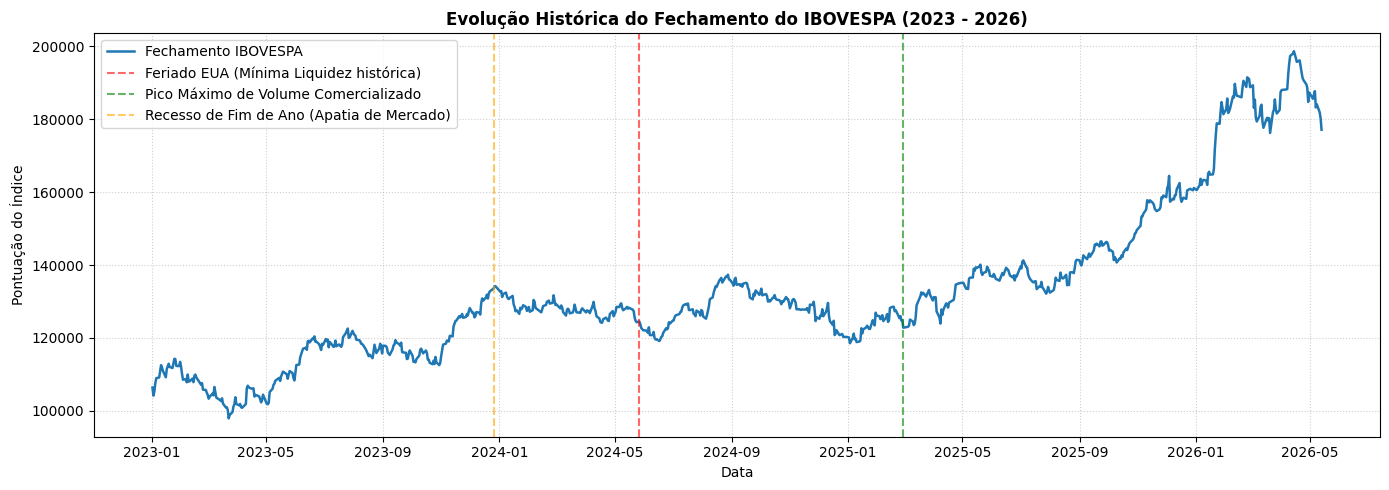

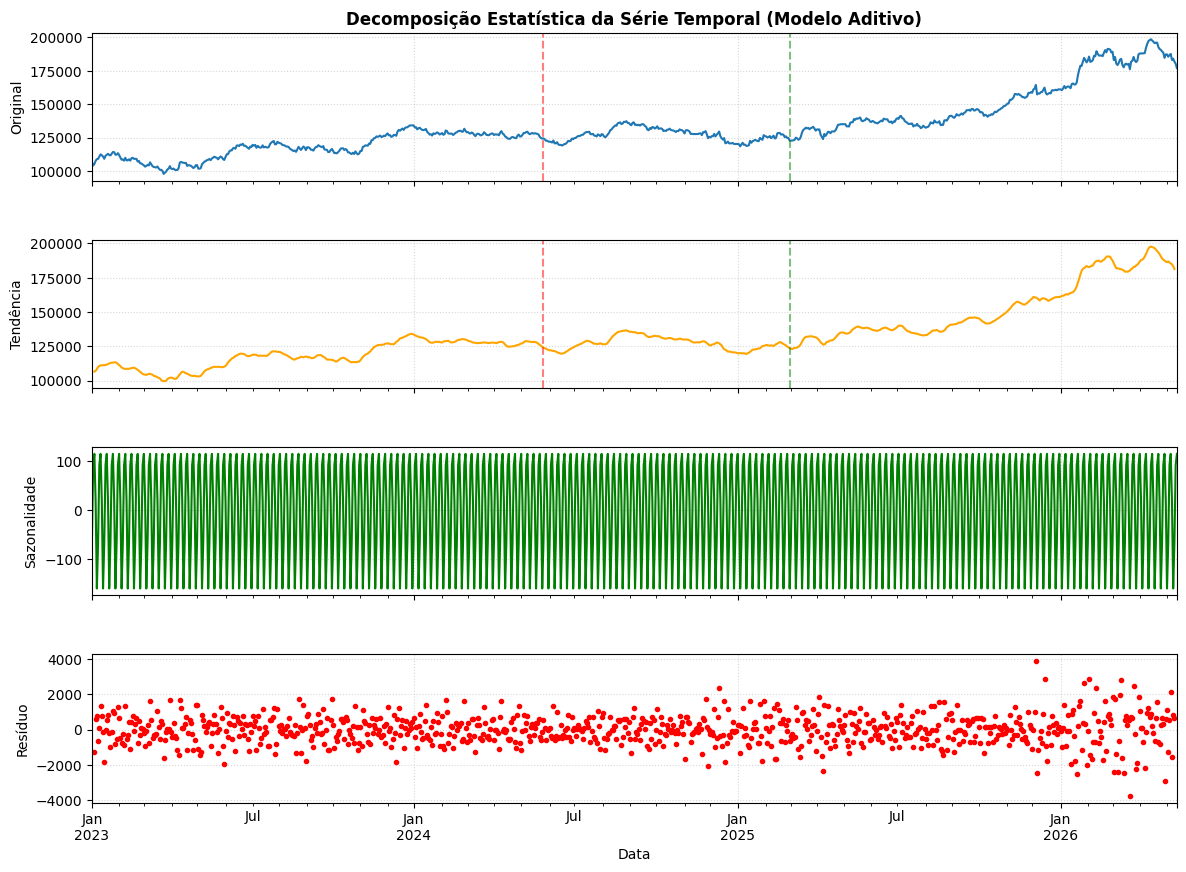

In [195]:
#####################################################################
# BLOCO 10 — VISUALIZAÇÃO HISTÓRICA E DECOMPOSIÇÃO DA SÉRIE TEMPORAL
# Análise Exploratória Avançada (EDA) & Análise Estatística
#####################################################################

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# -------------------------------------------------------------------
# PARTE 1: Gráfico de Evolução do Fechamento (Storytelling)
# -------------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Plotagem da linha principal de fechamento
plt.plot(
    df_ibovespa_idx.index,
    df_ibovespa_idx['fechamento'],
    label='Fechamento IBOVESPA',
    color='#1f77b4',
    linewidth=1.8
)

# Adicionando Linhas Verticais de Contexto Histórico (Storytelling)
plt.axvline(pd.to_datetime('2024-05-27'), color='red', linestyle='--', alpha=0.6,
            label='Feriado EUA (Mínima Liquidez histórica)')
plt.axvline(pd.to_datetime('2025-02-28'), color='green', linestyle='--', alpha=0.6,
            label='Pico Máximo de Volume Comercializado')
plt.axvline(pd.to_datetime('2023-12-26'), color='orange', linestyle='--', alpha=0.6,
            label='Recesso de Fim de Ano (Apatia de Mercado)')

# Títulos e estilização do primeiro gráfico
plt.title('Evolução Histórica do Fechamento do IBOVESPA (2023 - 2026)', fontsize=12, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Pontuação do Índice')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# PARTE 2: Decomposição Estatística da Série Temporal
# -------------------------------------------------------------------
# Executa a decomposição aditiva com período de 5 dias úteis
decomposicao = seasonal_decompose(serie_fechamento, model='additive', period=5)

# Configuração do painel com os 4 subgráficos
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# CORREÇÃO DE LAYOUT: Garante um espaçamento vertical ideal entre os gráficos
plt.subplots_adjust(hspace=0.4)

# 1. Componente Observado (Série Original)
decomposicao.observed.plot(ax=ax1, color='#1f77b4')
ax1.set_title('Decomposição Estatística da Série Temporal (Modelo Aditivo)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Original')
ax1.grid(True, linestyle=':', alpha=0.5)

# Rebatendo os marcos históricos no gráfico observado para manter o alinhamento
ax1.axvline(pd.to_datetime('2024-05-27'), color='red', linestyle='--', alpha=0.5)
ax1.axvline(pd.to_datetime('2025-02-28'), color='green', linestyle='--', alpha=0.5)

# 2. Componente de Tendência (Trend)
decomposicao.trend.plot(ax=ax2, color='orange')
ax2.set_ylabel('Tendência')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.axvline(pd.to_datetime('2024-05-27'), color='red', linestyle='--', alpha=0.5)
ax2.axvline(pd.to_datetime('2025-02-28'), color='green', linestyle='--', alpha=0.5)

# 3. Componente de Sazonalidade (Seasonal)
decomposicao.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Sazonalidade')
ax3.grid(True, linestyle=':', alpha=0.5)

# 4. Componente de Resíduo / Ruído (Resid)
decomposicao.resid.plot(ax=ax4, color='red', style='.')
ax4.set_ylabel('Resíduo')
ax4.grid(True, linestyle=':', alpha=0.5)

plt.xlabel('Data')
plt.show()

###  **Análise Exploratória e Decomposição Estatística da Série Temporal**

Neste bloco, consolidamos a análise visual e estatística do IBOVESPA através de duas abordagens complementares na mesma janela temporal (2023–2026):

1. **Evolução Histórica do Fechamento (Gráfico Superior):** Apresenta o comportamento real do índice ao longo do tempo. As marcações verticais sinalizam eventos de contexto que podem estar associados a mudanças de liquidez, como feriados externos, recesso de fim de ano e possíveis ajustes institucionais de carteira.

2. **Decomposição Matemática (Painel Inferior):** Utilizando o modelo aditivo da biblioteca `statsmodels` (com período fixado em 5 dias úteis), a série original foi quebrada em seus três componentes analíticos fundamentais:
   * **Tendência:** Isola a direção macroeconômica de longo prazo, limpando os ruídos diários.
   * **Sazonalidade:** Captura flutuações sistemáticas que se repetem ciclicamente dentro de uma semana típica de pregão do mercado.
   * **Resíduo (Ruído):** Evidencia eventos aleatórios e imprevisíveis (choques de notícias ou fatos relevantes) que causam volatilidade e não seguem padrões fixos.

Essa estrutura unificada fornece o embasamento estatístico essencial para compreender a dinâmica de volatilidade da nossa variável principal antes de alimentá-la no modelo preditivo.

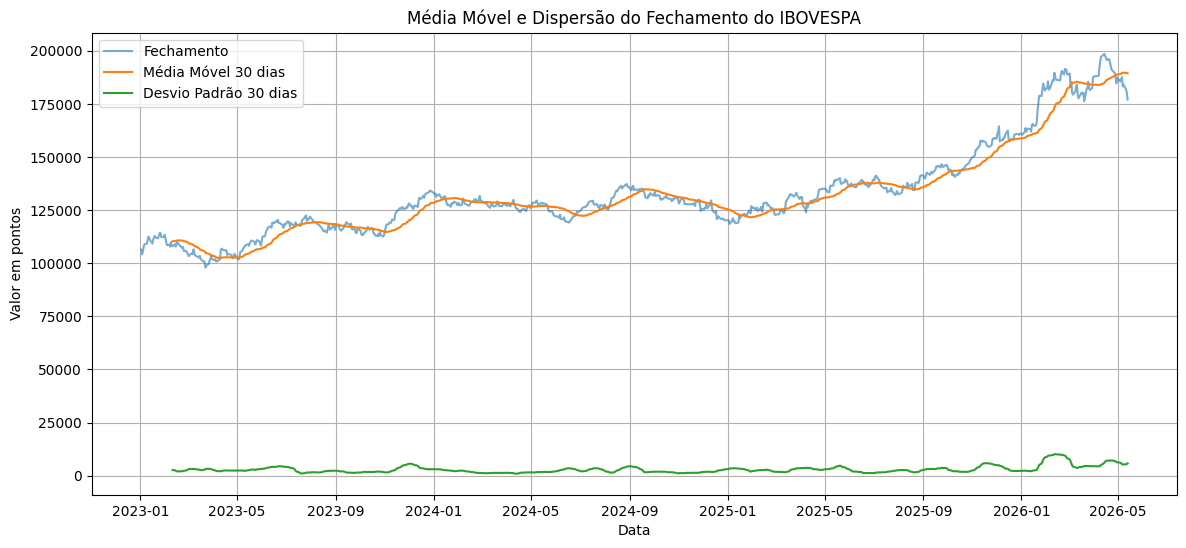

In [196]:
#####################################################################
# BLOCO 11 — MÉDIA MÓVEL E DESVIO PADRÃO DO FECHAMENTO
#####################################################################

# Média móvel de 30 dias do fechamento
rolling_mean_30 = df_ibovespa_idx['fechamento'].rolling(window=30).mean()

# Desvio padrão móvel de 30 dias do fechamento
rolling_std_30 = df_ibovespa_idx['fechamento'].rolling(window=30).std()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(df_ibovespa_idx['fechamento'], label='Fechamento', alpha=0.6)
plt.plot(rolling_mean_30, label='Média Móvel 30 dias')
plt.plot(rolling_std_30, label='Desvio Padrão 30 dias')

plt.title('Média Móvel e Dispersão do Fechamento do IBOVESPA')
plt.xlabel('Data')
plt.ylabel('Valor em pontos')

plt.legend()
plt.grid(True)
plt.show()

### **Bloco 11 — Análise do gráfico — Média móvel e dispersão do fechamento**

O gráfico apresenta a evolução do fechamento do IBOVESPA, sua média móvel de 30 dias e o desvio padrão móvel no mesmo período.

A média móvel suaviza as oscilações diárias e permite observar com mais clareza a tendência geral da série. No período analisado, é possível perceber uma trajetória de crescimento mais evidente a partir de 2025, com aceleração do índice até o início de 2026.

O desvio padrão móvel mostra a dispersão dos valores de fechamento ao longo do tempo. Observa-se aumento da dispersão em alguns períodos, especialmente próximo de 2026, indicando maior instabilidade nos valores do índice.

Essa análise contribui para o storytelling da série temporal, pois ajuda a identificar tendência, oscilações e momentos de maior instabilidade no comportamento do IBOVESPA.

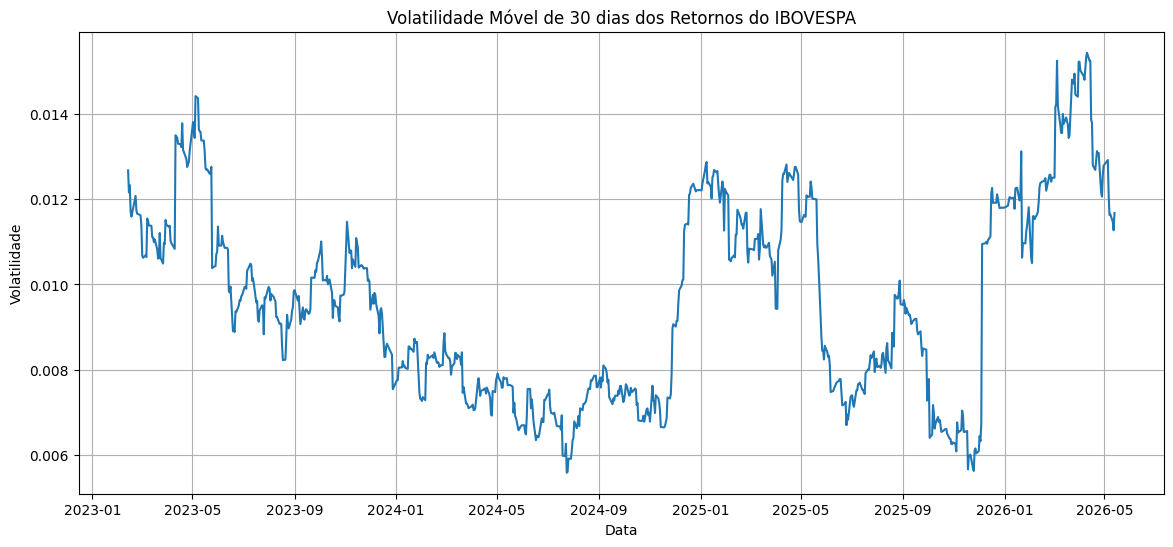

In [197]:
#####################################################################
# BLOCO 12 — VOLATILIDADE DOS RETORNOS DIÁRIOS
#####################################################################

# Calcula o retorno diário do fechamento
df_ibovespa_idx['retorno_diario'] = df_ibovespa_idx['fechamento'].pct_change()

# Calcula a volatilidade móvel de 30 dias com base nos retornos
df_ibovespa_idx['volatilidade_30d'] = df_ibovespa_idx['retorno_diario'].rolling(window=30).std()

# Plot
plt.figure(figsize=(14, 6))

plt.plot(df_ibovespa_idx['volatilidade_30d'])

plt.title('Volatilidade Móvel de 30 dias dos Retornos do IBOVESPA')
plt.xlabel('Data')
plt.ylabel('Volatilidade')

plt.grid(True)
plt.show()

### **BLOCO 12 — Análise do gráfico - Volatilidade dos retornos diários**

O gráfico apresenta a volatilidade móvel de 30 dias calculada a partir dos retornos diários do IBOVESPA.

Observa-se que a volatilidade não se manteve constante ao longo do período. Em parte de 2024, houve redução da instabilidade, indicando um comportamento mais estável dos retornos. Já no início de 2025 e, principalmente, no começo de 2026, a volatilidade voltou a subir.

Esse aumento indica períodos de maior oscilação do mercado, o que torna a previsão mais difícil e reforça a importância de utilizar variáveis temporais no modelo, como retornos, médias móveis, defasagens e medidas de volatilidade.

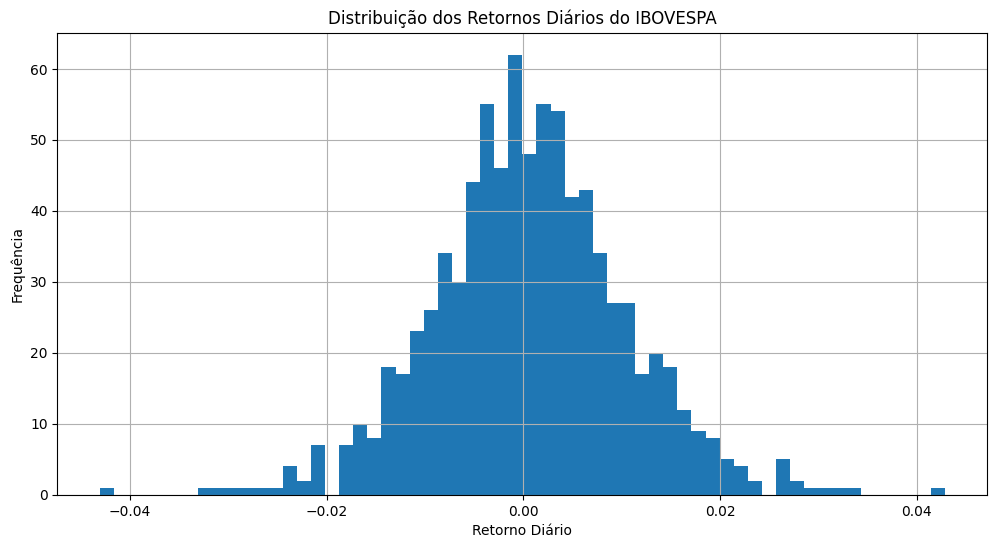

Resumo dos retornos diários:
count    837.000000
mean       0.000659
std        0.009943
min       -0.043094
25%       -0.005138
50%        0.000496
75%        0.006527
max        0.042878
Name: retorno_diario, dtype: float64

Maior alta diária: 0.04287804255402716
Maior queda diária: -0.04309359342316488


In [198]:
#####################################################################
# BLOCO 13 — HISTOGRAMA DOS RETORNOS DIÁRIOS
#####################################################################

# Remove valores nulos para análise
retornos = df_ibovespa_idx['retorno_diario'].dropna()

# Plot do histograma
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(retornos, bins=60)

plt.title('Distribuição dos Retornos Diários do IBOVESPA')
plt.xlabel('Retorno Diário')
plt.ylabel('Frequência')

plt.grid(True)
plt.show()

print("Resumo dos retornos diários:")
print(retornos.describe())

print("\nMaior alta diária:", retornos.max())
print("Maior queda diária:", retornos.min())

### **Bloco 13 — Análise do gráfico — Distribuição dos retornos diários**

O histograma mostra que a maior parte dos retornos diários do IBOVESPA está concentrada próxima de zero, indicando que, na maioria dos pregões, as variações foram moderadas.

Também é possível observar alguns retornos extremos, tanto negativos quanto positivos, representando dias de maior queda ou maior alta do índice.

A distribuição apresenta comportamento típico de séries financeiras: muitos movimentos pequenos e poucos eventos de grande oscilação. Esse padrão reforça a necessidade de usar variáveis como retornos, médias móveis, volatilidade e defasagens temporais na construção do modelo preditivo.


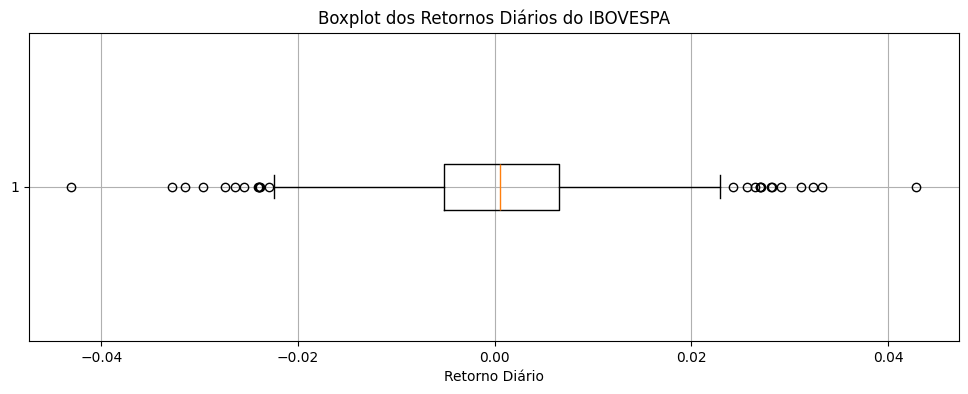

In [199]:
#####################################################################
# BLOCO 14 — BOXPLOT DOS RETORNOS DIÁRIOS
#####################################################################

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.boxplot(df_ibovespa_idx['retorno_diario'].dropna(), vert=False)

plt.title('Boxplot dos Retornos Diários do IBOVESPA')
plt.xlabel('Retorno Diário')
plt.grid(True)
plt.show()

## **Bloco 14 — Análise do gráfico — Boxplot dos retornos diários**

O boxplot dos retornos diários mostra que a maior parte das variações do IBOVESPA está concentrada próxima de zero, indicando predominância de oscilações moderadas no período analisado.

A mediana também se encontra próxima de zero, o que reforça que os movimentos diários mais comuns são pequenos.

Os pontos mais afastados representam outliers, ou seja, pregões com variações muito acima ou abaixo do padrão. Observam-se eventos extremos tanto de queda quanto de alta, próximos de -4% e +4%, indicando momentos de maior instabilidade no mercado.

Essa análise ajuda a identificar os picos de alta e baixa que serão detalhados na próxima etapa do storytelling.

In [200]:
#####################################################################
# BLOCO 15 — IDENTIFICAÇÃO DOS PICOS DE ALTA E BAIXA
#####################################################################

# Cria uma base auxiliar sem valores nulos de retorno
df_retornos = df_ibovespa_idx.dropna(subset=['retorno_diario']).copy()

# Cria retorno em percentual para facilitar a leitura
df_retornos['retorno_percentual'] = df_retornos['retorno_diario'] * 100

# 10 maiores altas
maiores_altas = (
    df_retornos
    .sort_values('retorno_diario', ascending=False)
    [['fechamento', 'retorno_percentual']]
    .head(10)
)

# 10 maiores baixas
maiores_baixas = (
    df_retornos
    .sort_values('retorno_diario', ascending=True)
    [['fechamento', 'retorno_percentual']]
    .head(10)
)

print("10 maiores altas diárias:")
print(maiores_altas.round(2))

print("\n10 maiores baixas diárias:")
print(maiores_baixas.round(2))

10 maiores altas diárias:
            fechamento  retorno_percentual
data                                      
2023-04-11      106214                4.29
2026-01-21      171817                3.33
2026-03-23      181932                3.24
2025-04-09      127796                3.12
2023-05-05      105148                2.91
2025-01-30      126913                2.82
2025-01-15      122650                2.81
2026-03-31      187462                2.71
2023-11-03      118160                2.70
2025-02-14      128219                2.70

10 maiores baixas diárias:
            fechamento  retorno_percentual
data                                      
2025-12-05      157369               -4.31
2026-03-03      183105               -3.28
2024-12-18      120772               -3.15
2025-04-04      127256               -2.96
2024-12-12      126042               -2.74
2026-03-05      180464               -2.64
2026-03-12      179284               -2.55
2025-12-16      158578               -2.40


### **BLOCO 15 - Análise dos picos de alta e baixa**

Neste bloco, foram identificados os 10 maiores retornos positivos e os 10 maiores retornos negativos do IBOVESPA no período analisado.

A maior alta diária ocorreu em **11/04/2023**, com valorização de **4,29%**. Também foram observadas altas relevantes em 2026 e 2025, indicando momentos de forte recuperação ou maior otimismo do mercado.

A maior baixa diária ocorreu em **05/12/2025**, com queda de **-4,31%**. Além disso, várias quedas expressivas aparecem em março de 2026, sugerindo um período de maior instabilidade no índice.

Esses picos mostram que, embora a maior parte dos retornos diários esteja próxima de zero, existem eventos extremos que afetam significativamente o comportamento da série. Essa característica é típica de séries financeiras e reforça a necessidade de utilizar variáveis como retornos, médias móveis, volatilidade e defasagens temporais na modelagem preditiva.

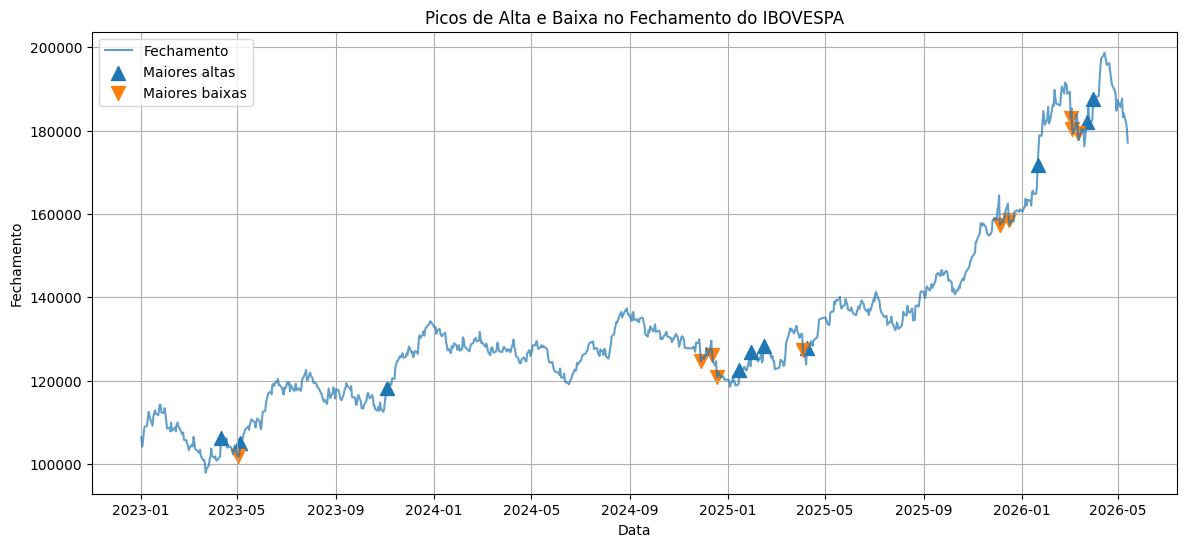

In [201]:
#####################################################################
# BLOCO 16 — VISUALIZAÇÃO DOS PICOS DE ALTA E BAIXA NA SÉRIE
#####################################################################

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Série principal
plt.plot(
    df_ibovespa_idx.index,
    df_ibovespa_idx['fechamento'],
    label='Fechamento',
    alpha=0.7
)

# Pontos das maiores altas
plt.scatter(
    maiores_altas.index,
    maiores_altas['fechamento'],
    label='Maiores altas',
    marker='^',
    s=100
)

# Pontos das maiores baixas
plt.scatter(
    maiores_baixas.index,
    maiores_baixas['fechamento'],
    label='Maiores baixas',
    marker='v',
    s=100
)

plt.title('Picos de Alta e Baixa no Fechamento do IBOVESPA')
plt.xlabel('Data')
plt.ylabel('Fechamento')
plt.legend()
plt.grid(True)
plt.show()

### **BLOCO 16 - Análise do gráfico — Picos de alta e baixa**

O gráfico apresenta a série histórica do fechamento do IBOVESPA com destaque para os principais picos de alta e baixa identificados pelos retornos diários.

Os marcadores de alta indicam os pregões em que o índice apresentou as maiores valorizações percentuais no período. Já os marcadores de baixa mostram os dias de maior queda percentual.

Essa visualização facilita o storytelling da série temporal, pois permite localizar os eventos extremos diretamente sobre a trajetória do índice. Observa-se que os picos não ocorrem de forma uniforme, mas aparecem concentrados em períodos específicos de maior instabilidade do mercado.

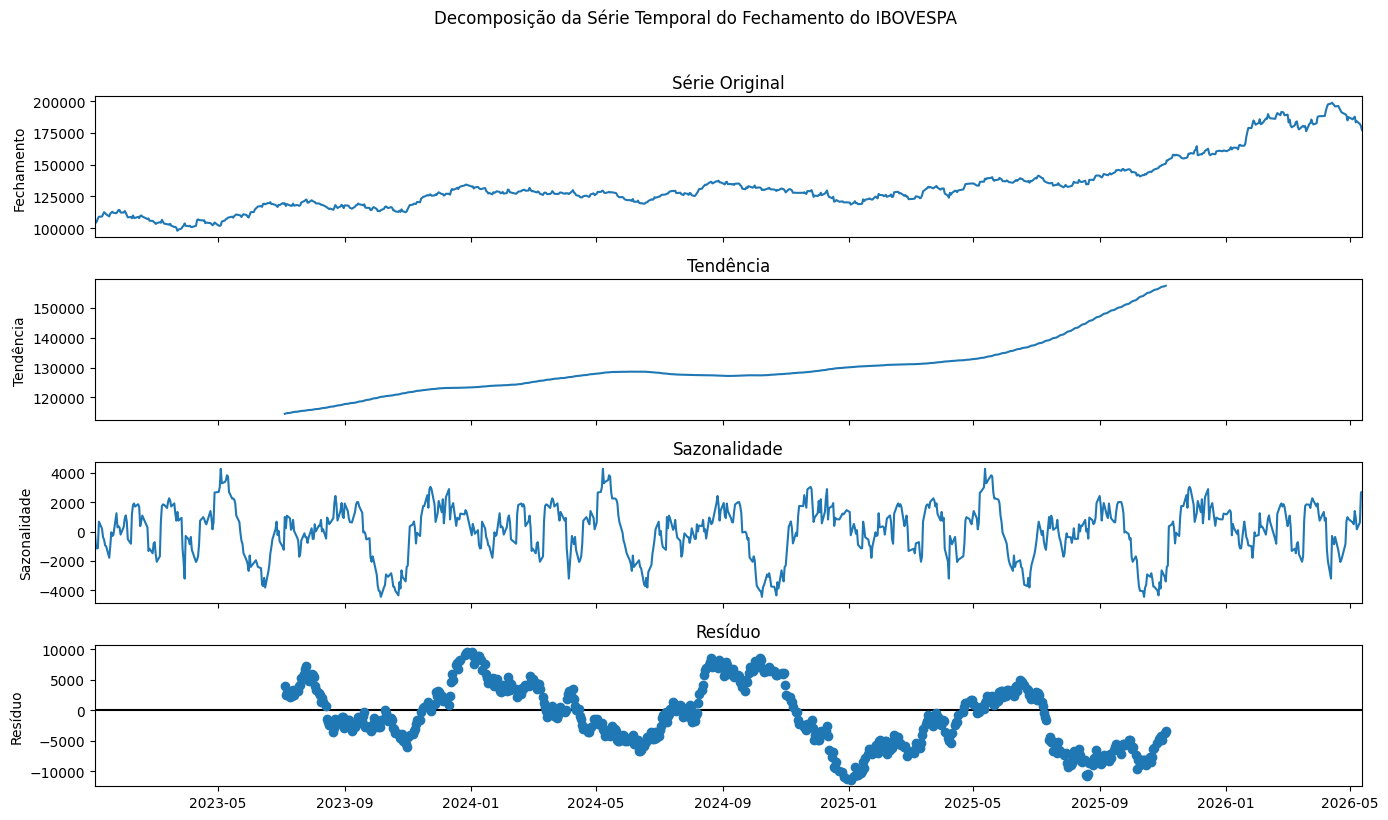

In [202]:
#####################################################################
# BLOCO 17 — DECOMPOSIÇÃO DA SÉRIE TEMPORAL
#####################################################################

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

serie_fechamento = df_ibovespa_idx['fechamento'].dropna()

decomposicao = seasonal_decompose(
    serie_fechamento,
    model='additive',
    period=252
)

fig = decomposicao.plot()
fig.set_size_inches(14, 8)

# Ajusta os títulos dos gráficos para português
fig.axes[0].set_ylabel('Fechamento')
fig.axes[1].set_ylabel('Tendência')
fig.axes[2].set_ylabel('Sazonalidade')
fig.axes[3].set_ylabel('Resíduo')

fig.axes[0].set_title('Série Original')
fig.axes[1].set_title('Tendência')
fig.axes[2].set_title('Sazonalidade')
fig.axes[3].set_title('Resíduo')

plt.suptitle('Decomposição da Série Temporal do Fechamento do IBOVESPA', y=1.02)
plt.tight_layout()
plt.show()

### **BLOCO 17 - Análise do gráfico — Decomposição da série temporal**

A decomposição da série temporal do fechamento do IBOVESPA separa o comportamento do índice em tendência, sazonalidade e resíduo.

No componente de **tendência**, observa-se uma trajetória geral de crescimento ao longo do período analisado. O movimento de alta torna-se mais evidente a partir de 2025, com aceleração mais forte até o início de 2026.

O componente **sazonal** apresenta oscilações recorrentes ao longo da série, indicando variações periódicas no comportamento do índice. Apesar disso, em séries financeiras, a sazonalidade costuma ser menos estável do que em séries econômicas ou operacionais tradicionais.

O componente **residual** mostra as variações que não são explicadas diretamente pela tendência nem pela sazonalidade. Esses resíduos evidenciam períodos de maior instabilidade, especialmente entre o final de 2024 e 2025, quando há oscilações mais intensas.

A decomposição confirma que o fechamento do IBOVESPA possui tendência relevante, oscilações periódicas e ruídos significativos. Isso reforça a necessidade de utilizar variáveis temporais, como defasagens, médias móveis, retornos e volatilidade, na construção do modelo preditivo.

In [203]:
#####################################################################
# BLOCO 18 — ENGENHARIA DE ATRIBUTOS TEMPORAIS
# PREPARAÇÃO DA BASE PARA MODELAGEM PREDITIVA
#####################################################################

# Cria uma cópia da base indexada
df_modelo = df_ibovespa_idx.copy()

# Retornos passados
df_modelo['retorno_1d'] = df_modelo['fechamento'].pct_change(1)
df_modelo['retorno_3d'] = df_modelo['fechamento'].pct_change(3)
df_modelo['retorno_5d'] = df_modelo['fechamento'].pct_change(5)

# Defasagens do fechamento
df_modelo['lag_1'] = df_modelo['fechamento'].shift(1)
df_modelo['lag_2'] = df_modelo['fechamento'].shift(2)
df_modelo['lag_3'] = df_modelo['fechamento'].shift(3)
df_modelo['lag_5'] = df_modelo['fechamento'].shift(5)

# Médias móveis
df_modelo['media_5'] = df_modelo['fechamento'].rolling(window=5).mean()
df_modelo['media_10'] = df_modelo['fechamento'].rolling(window=10).mean()
df_modelo['media_20'] = df_modelo['fechamento'].rolling(window=20).mean()
df_modelo['media_30'] = df_modelo['fechamento'].rolling(window=30).mean()

# Volatilidades dos retornos
df_modelo['volatilidade_5'] = df_modelo['retorno_1d'].rolling(window=5).std()
df_modelo['volatilidade_10'] = df_modelo['retorno_1d'].rolling(window=10).std()
df_modelo['volatilidade_30'] = df_modelo['retorno_1d'].rolling(window=30).std()

# Amplitude do pregão
df_modelo['amplitude_dia'] = (df_modelo['maxima'] - df_modelo['minima']) / df_modelo['fechamento']

# Variação entre abertura e fechamento
df_modelo['var_abertura_fechamento'] = (df_modelo['fechamento'] - df_modelo['abertura']) / df_modelo['abertura']

# Verificação inicial
df_modelo.info()

df_modelo = df_modelo.drop(columns=['volatilidade_30d'])

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 838 entries, 2023-01-02 to 2026-05-13
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fechamento               838 non-null    int64  
 1   abertura                 838 non-null    int64  
 2   maxima                   838 non-null    int64  
 3   minima                   838 non-null    int64  
 4   volume                   838 non-null    object 
 5   variacao                 838 non-null    object 
 6   variacao_num             838 non-null    float64
 7   volume_num               838 non-null    float64
 8   retorno_diario           837 non-null    float64
 9   volatilidade_30d         808 non-null    float64
 10  retorno_1d               837 non-null    float64
 11  retorno_3d               835 non-null    float64
 12  retorno_5d               833 non-null    float64
 13  lag_1                    837 non-null    float64
 14  lag_2  

### BLOCO 18 — Engenharia de atributos temporais

Neste bloco, foram criadas variáveis temporais para preparar a base de modelagem.

Foram gerados retornos passados, defasagens do fechamento, médias móveis, volatilidades, amplitude diária e variação entre abertura e fechamento.

A verificação com info() mostra que a base passou a ter 26 colunas. Os valores nulos observados nas variáveis temporais são esperados, pois decorrem do uso de defasagens e janelas móveis.

In [204]:
#####################################################################
# BLOCO 19 — DEFINIÇÃO DA VARIÁVEL ALVO
# PREPARAÇÃO DA BASE PARA MODELAGEM PREDITIVA
#####################################################################

# Define o alvo da previsão: fechamento do próximo pregão
df_modelo['target_fechamento'] = df_modelo['fechamento'].shift(-1)

# Cria também a direção do próximo pregão para medir assertividade direcional
df_modelo['target_direcao'] = (
    df_modelo['target_fechamento'] > df_modelo['fechamento']
).astype(int)

# Verificação
df_modelo[
    [
        'fechamento',
        'target_fechamento',
        'target_direcao'
    ]
].tail(10)

,fechamento,target_fechamento,target_direcao
data,,,
2026-04-29,184750,187318.0,1
2026-04-30,187318,185600.0,0
2026-05-04,185600,186754.0,1
2026-05-05,186754,187691.0,1
2026-05-06,187691,183218.0,0
2026-05-07,183218,184108.0,1
2026-05-08,184108,181909.0,0
2026-05-11,181909,180342.0,0
2026-05-12,180342,177098.0,0


### **BLOCO 19 — Definição da variável alvo**

A variável principal da modelagem é **target_fechamento**, criada para representar o fechamento do próximo pregão do IBOVESPA.

Essa estrutura permite que o modelo utilize informações disponíveis até o pregão atual para prever o valor de fechamento do pregão seguinte, respeitando a lógica temporal da série.

A variável **target_direcao** foi criada apenas como apoio para avaliar a assertividade direcional do modelo, indicando se o fechamento previsto aponta para alta ou baixa em relação ao fechamento atual.

In [205]:
#####################################################################
# BLOCO 20 — LIMPEZA DA BASE DE MODELAGEM
# PREPARAÇÃO DA BASE PARA MODELAGEM PREDITIVA
######################################################################

# Remove colunas textuais que não serão usadas diretamente no modelo
df_modelo_limpo = df_modelo.drop(columns=['volume', 'variacao'], errors='ignore')

# Remove registros com valores nulos gerados por lags, médias móveis,
# volatilidades e target futuro
df_modelo_limpo = df_modelo_limpo.dropna()

# Verificação da base final para modelagem
print("Dimensão antes da limpeza:", df_modelo.shape)
print("Dimensão após a limpeza:", df_modelo_limpo.shape)

print("\nValores nulos restantes:")
print(df_modelo_limpo.isna().sum())

print("\nInformações da base limpa:")
print(df_modelo_limpo.info())

Dimensão antes da limpeza: (838, 27)
Dimensão após a limpeza: (807, 25)

Valores nulos restantes:
fechamento                 0
abertura                   0
maxima                     0
minima                     0
variacao_num               0
volume_num                 0
retorno_diario             0
retorno_1d                 0
retorno_3d                 0
retorno_5d                 0
lag_1                      0
lag_2                      0
lag_3                      0
lag_5                      0
media_5                    0
media_10                   0
media_20                   0
media_30                   0
volatilidade_5             0
volatilidade_10            0
volatilidade_30            0
amplitude_dia              0
var_abertura_fechamento    0
target_fechamento          0
target_direcao             0
dtype: int64

Informações da base limpa:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 807 entries, 2023-02-13 to 2026-05-12
Data columns (total 25 columns):
 #   Column 

### **BLOCO 20 — Limpeza da base de modelagem**

Neste bloco, foi realizada a limpeza final da base preparada para modelagem.

Foram removidas as colunas textuais que não serão utilizadas diretamente pelo modelo e também os registros com valores nulos gerados pelas defasagens, médias móveis, volatilidades e pela variável alvo futura.

Essa etapa garante que a base esteja consistente, sem valores ausentes e pronta para a separação entre treino e teste.

In [206]:
#####################################################################
# BLOCO 21 — SELEÇÃO DAS VARIÁVEIS EXPLICATIVAS E DO ALVO
# PREPARAÇÃO DA BASE PARA MODELAGEM PREDITIVA
#####################################################################

# Define as variáveis explicativas que serão usadas pelo modelo
features = [
    'fechamento',
    'abertura',
    'maxima',
    'minima',
    'variacao_num',
    'volume_num',
    'retorno_1d',
    'retorno_3d',
    'retorno_5d',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_5',
    'media_5',
    'media_10',
    'media_20',
    'media_30',
    'volatilidade_5',
    'volatilidade_10',
    'volatilidade_30',
    'amplitude_dia',
    'var_abertura_fechamento'
]

# Define X e y
X = df_modelo_limpo[features]
y = df_modelo_limpo['target_fechamento']

# Variável complementar para avaliação direcional
y_direcao = df_modelo_limpo['target_direcao']

# Verificações
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
print("Dimensão de y_direcao:", y_direcao.shape)

print("\nVariáveis explicativas:")
print(X.columns.tolist())

Dimensão de X: (807, 22)
Dimensão de y: (807,)
Dimensão de y_direcao: (807,)

Variáveis explicativas:
['fechamento', 'abertura', 'maxima', 'minima', 'variacao_num', 'volume_num', 'retorno_1d', 'retorno_3d', 'retorno_5d', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'media_5', 'media_10', 'media_20', 'media_30', 'volatilidade_5', 'volatilidade_10', 'volatilidade_30', 'amplitude_dia', 'var_abertura_fechamento']


### **Análise da saída — Seleção das variáveis explicativas e do alvo**

Após a limpeza da base, foram mantidos **807 registros válidos** para a modelagem.

A matriz de variáveis explicativas **X** ficou com **22 variáveis**, incluindo preços, volume, retornos, defasagens, médias móveis, volatilidades e medidas de oscilação do pregão.

A variável alvo principal **y** possui o mesmo número de registros e representa o fechamento do próximo pregão do IBOVESPA.

Também foi mantida a variável **y_direcao**, com 807 registros, para posterior avaliação da assertividade direcional do modelo.

In [207]:
#####################################################################
# BLOCO 22 — SEPARAÇÃO CRONOLÓGICA ENTRE TREINO E TESTE
#####################################################################

# Define o percentual de dados para treino
percentual_treino = 0.80

# Calcula o ponto de corte respeitando a ordem temporal
ponto_corte = int(len(X) * percentual_treino)

# Separação cronológica
X_train = X.iloc[:ponto_corte]
X_test = X.iloc[ponto_corte:]

y_train = y.iloc[:ponto_corte]
y_test = y.iloc[ponto_corte:]

y_direcao_train = y_direcao.iloc[:ponto_corte]
y_direcao_test = y_direcao.iloc[ponto_corte:]

# Verificações
print("Dimensão X_train:", X_train.shape)
print("Dimensão X_test:", X_test.shape)

print("\nDimensão y_train:", y_train.shape)
print("Dimensão y_test:", y_test.shape)

print("\nPeríodo de treino:")
print("Início:", X_train.index.min())
print("Fim:", X_train.index.max())

print("\nPeríodo de teste:")
print("Início:", X_test.index.min())
print("Fim:", X_test.index.max())

Dimensão X_train: (645, 22)
Dimensão X_test: (162, 22)

Dimensão y_train: (645,)
Dimensão y_test: (162,)

Período de treino:
Início: 2023-02-13 00:00:00
Fim: 2025-09-12 00:00:00

Período de teste:
Início: 2025-09-15 00:00:00
Fim: 2026-05-12 00:00:00


### **Separação cronológica entre treino e teste**

A separação entre treino e teste foi realizada respeitando a ordem temporal da série, sem embaralhamento dos dados.

A base foi dividida em **645 registros para treino** e **162 registros para teste**, mantendo as mesmas **22 variáveis explicativas** em ambos os conjuntos.

O período de treino vai de **13/02/2023 a 12/09/2025**, enquanto o período de teste vai de **15/09/2025 a 12/05/2026**.

Essa abordagem é adequada para séries temporais, pois evita vazamento de informação do futuro para o passado e permite avaliar o modelo em um cenário mais próximo do uso real, no qual os dados históricos são usados para prever períodos posteriores.

In [208]:
#####################################################################
# BLOCO 23 — MODELO BASELINE PARA COMPARAÇÃO
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import numpy as np

# Baseline: assume que o fechamento do próximo pregão será igual ao fechamento atual
baseline_pred = X_test['fechamento']

# Métricas de erro para previsão do fechamento
mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_baseline = r2_score(y_test, baseline_pred)

# Avaliação direcional do baseline
direcao_real_baseline = (y_test > X_test['fechamento']).astype(int)
direcao_prevista_baseline = (baseline_pred > X_test['fechamento']).astype(int)

acuracia_direcional_baseline = accuracy_score(
    direcao_real_baseline,
    direcao_prevista_baseline
)

# Exibição dos resultados
print("MODELO BASELINE — FECHAMENTO ATUAL COMO PREVISÃO DO PRÓXIMO PREGÃO")
print("-" * 70)

print("MAE:", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("R²:", round(r2_baseline, 4))
print("Acurácia direcional:", round(acuracia_direcional_baseline, 4))

MODELO BASELINE — FECHAMENTO ATUAL COMO PREVISÃO DO PRÓXIMO PREGÃO
----------------------------------------------------------------------
MAE: 1466.66
RMSE: 2002.95
R²: 0.9869
Acurácia direcional: 0.4136


### **Análise da saída — Modelo baseline**

O modelo baseline utiliza uma regra simples: considera que o fechamento do próximo pregão será igual ao fechamento do pregão atual.

Esse modelo serve como referência inicial para comparação com os modelos preditivos treinados posteriormente.

Os resultados obtidos foram:

| Métrica | Resultado | Interpretação |
|---|---:|---|
| MAE | 1.466,66 | Erro médio absoluto de aproximadamente 1.467 pontos |
| RMSE | 2.002,95 | Erro que penaliza mais fortemente desvios maiores |
| R² | 0,9869 | Alta aderência aos valores de fechamento |
| Acurácia direcional | 0,4136 | Baixa capacidade de prever corretamente alta ou baixa |

O objetivo principal da prova substitutiva é prever o valor de fechamento do IBOVESPA. Por isso, a métrica principal adotada será o MAE, que avalia o erro médio da previsão em pontos do índice. As demais métricas, como RMSE, R² e acurácia direcional, serão usadas apenas como apoio interpretativo.

Apesar do R² elevado, esse resultado deve ser interpretado com cautela. Em séries de preços, como o IBOVESPA, o fechamento de um pregão costuma ser próximo ao fechamento anterior, o que pode gerar alta aderência mesmo em modelos simples.

Por outro lado, a acurácia direcional de **41,36%** mostra que o baseline tem baixa capacidade de antecipar se o próximo fechamento será de alta ou de baixa.

Assim, o baseline será usado apenas como referência comparativa, não como modelo final.



In [209]:
#####################################################################
# BLOCO 24 — MODELO RANDOM FOREST REGRESSOR
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import numpy as np

# Criação do modelo
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Treinamento do modelo
modelo_rf.fit(X_train, y_train)

# Predição no conjunto de teste
pred_rf = modelo_rf.predict(X_test)

# Métricas para previsão do fechamento
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

# Avaliação direcional
direcao_real_rf = (y_test > X_test['fechamento']).astype(int)
direcao_prevista_rf = (pred_rf > X_test['fechamento']).astype(int)

acuracia_direcional_rf = accuracy_score(
    direcao_real_rf,
    direcao_prevista_rf
)

# Exibição dos resultados
print("MODELO RANDOM FOREST REGRESSOR")
print("-" * 70)

print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 4))
print("Acurácia direcional:", round(acuracia_direcional_rf, 4))

MODELO RANDOM FOREST REGRESSOR
----------------------------------------------------------------------
MAE: 26239.42
RMSE: 31506.95
R²: -2.2414
Acurácia direcional: 0.4198


### **Análise - Random Forest Regressor**

O modelo **Random Forest Regressor** apresentou desempenho inferior ao baseline.

Os resultados obtidos foram:

| Métrica | Resultado | Interpretação |
|---|---:|---|
| MAE | 26.239,42 | Erro médio absoluto elevado |
| RMSE | 31.506,95 | Erro alto, com maior penalização para grandes desvios |
| R² | -2,2414 | Desempenho inferior a uma previsão simples pela média |
| Acurácia direcional | 0,4198 | Baixa capacidade de prever corretamente alta ou baixa |

Os resultados indicam que o Random Forest não conseguiu generalizar bem para o período de teste. Embora seja um modelo robusto para muitos problemas de regressão, ele pode apresentar dificuldade em séries temporais financeiras com forte tendência e valores futuros acima da faixa observada no treinamento.

No período de teste, de setembro de 2025 a maio de 2026, o IBOVESPA apresentou forte valorização. Como o Random Forest é baseado em árvores de decisão, sua capacidade de extrapolar valores acima do intervalo aprendido no treino é limitada.

A acurácia direcional de **41,98%** também ficou abaixo do desejado, indicando que o modelo não foi eficiente para antecipar a direção do próximo fechamento.

Dessa forma, o Random Forest não será adotado como modelo final nesta etapa, mas seu resultado é importante como comparação com outras abordagens.

In [210]:
#####################################################################
# BLOCO 25 — MODELO DE REGRESSÃO LINEAR
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import numpy as np

# Criação do modelo
modelo_lr = LinearRegression()

# Treinamento do modelo
modelo_lr.fit(X_train, y_train)

# Predição no conjunto de teste
pred_lr = modelo_lr.predict(X_test)

# Métricas para previsão do fechamento
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

# Avaliação direcional
direcao_real_lr = (y_test > X_test['fechamento']).astype(int)
direcao_prevista_lr = (pred_lr > X_test['fechamento']).astype(int)

acuracia_direcional_lr = accuracy_score(
    direcao_real_lr,
    direcao_prevista_lr
)

# Exibição dos resultados
print("MODELO REGRESSÃO LINEAR")
print("-" * 70)

print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 4))
print("Acurácia direcional:", round(acuracia_direcional_lr, 4))

MODELO REGRESSÃO LINEAR
----------------------------------------------------------------------
MAE: 1564.8
RMSE: 2082.37
R²: 0.9858
Acurácia direcional: 0.4444


### **Análise — Regressão Linear**

O modelo **Regressão Linear** apresentou desempenho próximo ao baseline na previsão do fechamento do próximo pregão.

Os resultados obtidos foram:

| Métrica | Resultado | Interpretação |
|---|---:|---|
| MAE | 1.564,80 | Erro médio absoluto de aproximadamente 1.565 pontos |
| RMSE | 2.082,37 | Erro com maior penalização para desvios maiores |
| R² | 0,9858 | Alta aderência aos valores reais de fechamento |
| Acurácia direcional | 0,4444 | Baixa capacidade de prever corretamente alta ou baixa |

A Regressão Linear apresentou MAE de **1.564,80**, um pouco acima do baseline, que teve MAE de **1.466,66**. Isso indica que, em média, o modelo errou mais pontos do IBOVESPA do que a regra simples de repetir o fechamento atual.

O R² elevado mostra que o modelo acompanha bem o nível geral da série, mas esse resultado deve ser interpretado com cautela, pois séries de preço tendem a ter valores consecutivos muito próximos.

A acurácia direcional de **44,44%** ficou abaixo do desejado, indicando que o modelo ainda não conseguiu antecipar bem a direção do próximo fechamento.

Dessa forma, a Regressão Linear também não será adotada como modelo final neste momento, mas serve como comparação importante por ser um modelo simples, interpretável e alinhado a problemas de regressão.

In [211]:
#####################################################################
# BLOCO 26 — MODELO GRADIENT BOOSTING REGRESSOR
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import numpy as np

# Criação do modelo
modelo_gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Treinamento do modelo
modelo_gb.fit(X_train, y_train)

# Predição no conjunto de teste
pred_gb = modelo_gb.predict(X_test)

# Métricas para previsão do fechamento
mae_gb = mean_absolute_error(y_test, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
r2_gb = r2_score(y_test, pred_gb)

# Avaliação direcional
direcao_real_gb = (y_test > X_test['fechamento']).astype(int)
direcao_prevista_gb = (pred_gb > X_test['fechamento']).astype(int)

acuracia_direcional_gb = accuracy_score(
    direcao_real_gb,
    direcao_prevista_gb
)

# Exibição dos resultados
print("MODELO GRADIENT BOOSTING REGRESSOR")
print("-" * 70)

print("MAE:", round(mae_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R²:", round(r2_gb, 4))
print("Acurácia direcional:", round(acuracia_direcional_gb, 4))

MODELO GRADIENT BOOSTING REGRESSOR
----------------------------------------------------------------------
MAE: 26305.73
RMSE: 31480.06
R²: -2.2359
Acurácia direcional: 0.4198


### **Análise — Gradient Boosting Regressor**

O modelo **Gradient Boosting Regressor** apresentou desempenho inferior ao baseline.

Os resultados obtidos foram:

| Métrica | Resultado | Interpretação |
|---|---:|---|
| MAE | 26.305,73 | Erro médio absoluto elevado |
| RMSE | 31.480,06 | Erro alto, com maior penalização para grandes desvios |
| R² | -2,2359 | Desempenho inferior a uma previsão simples pela média |
| Acurácia direcional | 0,4198 | Baixa capacidade de prever corretamente alta ou baixa |

Os resultados indicam que o Gradient Boosting também não conseguiu generalizar bem para o período de teste. Embora seja um modelo forte para muitos problemas de regressão, ele apresentou dificuldade para acompanhar a forte valorização do IBOVESPA no período posterior ao treinamento.

Assim como ocorreu com o Random Forest, o Gradient Boosting é baseado em árvores de decisão. Esse tipo de modelo tende a ter dificuldade para extrapolar valores acima da faixa observada no conjunto de treino.

A acurácia direcional de **41,98%** ficou abaixo do desejado, mostrando que o modelo também não foi eficiente para antecipar a direção do próximo fechamento.

Dessa forma, o Gradient Boosting não será adotado como modelo final nesta etapa, mas seu resultado é útil para comparação e reforça a necessidade de testar abordagens mais adequadas à tendência da série temporal.

In [212]:
#####################################################################
# BLOCO 27 — MODELO KNN REGRESSOR
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import numpy as np

# Criação do modelo com padronização
# KNN é sensível à escala, por isso usamos StandardScaler
modelo_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

# Treinamento do modelo
modelo_knn.fit(X_train, y_train)

# Predição no conjunto de teste
pred_knn = modelo_knn.predict(X_test)

# Métricas para previsão do fechamento
mae_knn = mean_absolute_error(y_test, pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, pred_knn))
r2_knn = r2_score(y_test, pred_knn)

# Avaliação direcional complementar
direcao_real_knn = (y_test > X_test['fechamento']).astype(int)
direcao_prevista_knn = (pred_knn > X_test['fechamento']).astype(int)

acuracia_direcional_knn = accuracy_score(
    direcao_real_knn,
    direcao_prevista_knn
)

# Exibição dos resultados
print("MODELO KNN REGRESSOR")
print("-" * 70)

print("MAE:", round(mae_knn, 2))
print("RMSE:", round(rmse_knn, 2))
print("R²:", round(r2_knn, 4))
print("Acurácia direcional:", round(acuracia_direcional_knn, 4))

MODELO KNN REGRESSOR
----------------------------------------------------------------------
MAE: 26818.67
RMSE: 31776.65
R²: -2.2971
Acurácia direcional: 0.4136


### **Análise — KNN Regressor**

O modelo **KNN Regressor** foi testado como alternativa para previsão do fechamento do próximo pregão do IBOVESPA.

Como o KNN é um modelo sensível à escala dos dados, foi utilizado **StandardScaler** em pipeline antes do treinamento.

Os resultados obtidos foram:

| Métrica | Resultado | Interpretação |
|---|---:|---|
| MAE | 26.818,67 | Erro médio absoluto elevado |
| RMSE | 31.776,65 | Erro alto, com maior penalização para grandes desvios |
| R² | -2,2971 | Desempenho inferior a uma previsão simples pela média |
| Acurácia direcional | 0,4136 | Baixa capacidade de prever corretamente alta ou baixa |

O resultado mostra que o KNN não conseguiu generalizar bem para o período de teste. O erro médio ficou muito acima do Baseline e da Regressão Linear.

Dessa forma, o KNN Regressor não será adotado como modelo final, mas seu teste é útil porque o modelo está relacionado ao conteúdo estudado na disciplina e amplia a comparação entre abordagens.

In [213]:
#####################################################################
# BLOCO 28 — MODELO SVR
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import numpy as np

# Criação do modelo com padronização
# SVR também é sensível à escala, por isso usamos StandardScaler
modelo_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=100, epsilon=0.1))
])

# Treinamento do modelo
modelo_svr.fit(X_train, y_train)

# Predição no conjunto de teste
pred_svr = modelo_svr.predict(X_test)

# Métricas para previsão do fechamento
mae_svr = mean_absolute_error(y_test, pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, pred_svr))
r2_svr = r2_score(y_test, pred_svr)

# Avaliação direcional complementar
direcao_real_svr = (y_test > X_test['fechamento']).astype(int)
direcao_prevista_svr = (pred_svr > X_test['fechamento']).astype(int)

acuracia_direcional_svr = accuracy_score(
    direcao_real_svr,
    direcao_prevista_svr
)

# Exibição dos resultados
print("MODELO SVR")
print("-" * 70)

print("MAE:", round(mae_svr, 2))
print("RMSE:", round(rmse_svr, 2))
print("R²:", round(r2_svr, 4))
print("Acurácia direcional:", round(acuracia_direcional_svr, 4))

MODELO SVR
----------------------------------------------------------------------
MAE: 42938.59
RMSE: 47127.95
R²: -6.2523
Acurácia direcional: 0.4136


### **Análise — SVR**

O modelo **SVR** foi testado como uma alternativa baseada em Support Vector Machine para regressão.

Assim como o KNN, o SVR é sensível à escala dos dados. Por esse motivo, também foi utilizado **StandardScaler** em pipeline antes do treinamento.

Os resultados obtidos foram:

| Métrica | Resultado | Interpretação |
|---|---:|---|
| MAE | 42.938,59 | Erro médio absoluto muito elevado |
| RMSE | 47.127,95 | Erro alto, indicando grandes desvios nas previsões |
| R² | -6,2523 | Desempenho muito inferior a uma previsão simples pela média |
| Acurácia direcional | 0,4136 | Baixa capacidade de prever corretamente alta ou baixa |

O SVR apresentou o pior desempenho entre os modelos testados. O MAE elevado indica que o modelo não conseguiu acompanhar adequadamente os valores reais de fechamento no período de teste.

Dessa forma, o SVR não será adotado como modelo final. Seu resultado reforça que, para esta base e esta configuração, modelos mais complexos não necessariamente apresentam melhor desempenho.

In [214]:
#####################################################################
# BLOCO 29 — COMPARAÇÃO FINAL DOS MODELOS TESTADOS
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

import pandas as pd

# Consolida os resultados dos modelos avaliados
resultados_modelos = pd.DataFrame({
    "modelo": [
        "Baseline",
        "Random Forest Regressor",
        "Regressão Linear",
        "Gradient Boosting Regressor",
        "KNN Regressor",
        "SVR"
    ],
    "MAE": [
        mae_baseline,
        mae_rf,
        mae_lr,
        mae_gb,
        mae_knn,
        mae_svr
    ],
    "RMSE": [
        rmse_baseline,
        rmse_rf,
        rmse_lr,
        rmse_gb,
        rmse_knn,
        rmse_svr
    ],
    "R2": [
        r2_baseline,
        r2_rf,
        r2_lr,
        r2_gb,
        r2_knn,
        r2_svr
    ],
    "acuracia_direcional": [
        acuracia_direcional_baseline,
        acuracia_direcional_rf,
        acuracia_direcional_lr,
        acuracia_direcional_gb,
        acuracia_direcional_knn,
        acuracia_direcional_svr
    ]
})

# Ordena pelo menor MAE, métrica principal de erro
resultados_modelos = resultados_modelos.sort_values(by="MAE").reset_index(drop=True)

# Exibe a comparação
print("COMPARAÇÃO FINAL DOS MODELOS TESTADOS")
print("-" * 70)

print(
    resultados_modelos.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 4,
        "acuracia_direcional": 4
    })
)

# Identifica o melhor modelo pelo MAE
melhor_modelo = resultados_modelos.iloc[0]

print("\nMelhor modelo pelo MAE:")
print(melhor_modelo["modelo"])

print("\nMAE do melhor modelo:", round(melhor_modelo["MAE"], 2))
print("RMSE do melhor modelo:", round(melhor_modelo["RMSE"], 2))
print("R² do melhor modelo:", round(melhor_modelo["R2"], 4))
print("Acurácia direcional:", round(melhor_modelo["acuracia_direcional"], 4))

COMPARAÇÃO FINAL DOS MODELOS TESTADOS
----------------------------------------------------------------------
                        modelo       MAE      RMSE      R2  \
0                     Baseline   1466.66   2002.95  0.9869   
1             Regressão Linear   1564.80   2082.37  0.9858   
2      Random Forest Regressor  26239.42  31506.95 -2.2414   
3  Gradient Boosting Regressor  26305.73  31480.06 -2.2359   
4                KNN Regressor  26818.67  31776.65 -2.2971   
5                          SVR  42938.59  47127.95 -6.2523   

   acuracia_direcional  
0               0.4136  
1               0.4444  
2               0.4198  
3               0.4198  
4               0.4136  
5               0.4136  

Melhor modelo pelo MAE:
Baseline

MAE do melhor modelo: 1466.66
RMSE do melhor modelo: 2002.95
R² do melhor modelo: 0.9869
Acurácia direcional: 0.4136


### **Comparação final dos modelos testados**

A comparação final reuniu os resultados dos modelos avaliados: Baseline, Regressão Linear, Random Forest Regressor, Gradient Boosting Regressor, KNN Regressor e SVR.

Os resultados obtidos foram:

| Modelo | MAE | RMSE | R² | Acurácia direcional |
|---|---:|---:|---:|---:|
| Baseline | 1.466,66 | 2.002,95 | 0,9869 | 0,4136 |
| Regressão Linear | 1.564,80 | 2.082,37 | 0,9858 | 0,4444 |
| Random Forest Regressor | 26.239,42 | 31.506,95 | -2,2414 | 0,4198 |
| Gradient Boosting Regressor | 26.305,73 | 31.480,06 | -2,2359 | 0,4198 |
| KNN Regressor | 26.818,67 | 31.776,65 | -2,2971 | 0,4136 |
| SVR | 42.938,59 | 47.127,95 | -6,2523 | 0,4136 |

O **Baseline** apresentou o menor MAE, com erro médio de **1.466,66 pontos**. Porém, ele não é um modelo treinado, pois apenas considera que o fechamento do próximo pregão será igual ao fechamento atual. Por isso, será mantido apenas como referência comparativa.

Entre os modelos efetivamente treinados, a **Regressão Linear** apresentou o melhor desempenho, com **MAE de 1.564,80**, **RMSE de 2.082,37** e **R² de 0,9858**.

Os modelos Random Forest, Gradient Boosting, KNN e SVR apresentaram erros muito superiores e R² negativo, indicando baixa capacidade de generalização para o período de teste.

A acurácia direcional ficou baixa em todos os modelos, abaixo de 50%. Isso indica que os modelos não foram eficientes para prever a direção diária de alta ou baixa do índice.

Como o objetivo principal da prova substitutiva é prever o valor de fechamento do IBOVESPA, a métrica principal considerada foi o **MAE**. Assim, a **Regressão Linear** será mantida como o melhor modelo treinado e utilizada na etapa de previsão futura.

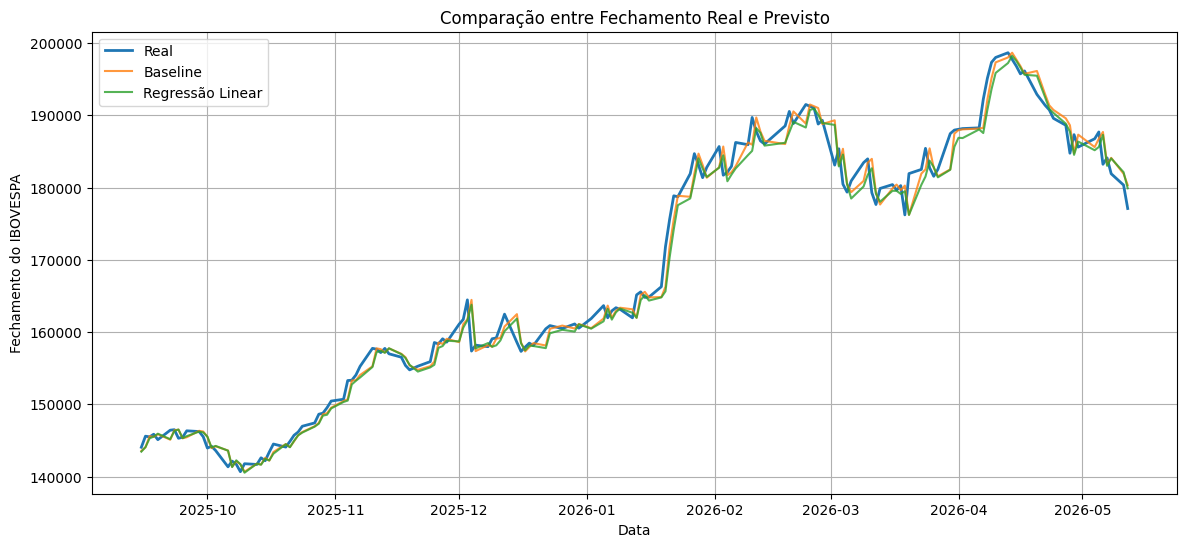

In [215]:
#####################################################################
# BLOCO 30 — COMPARAÇÃO VISUAL ENTRE REAL E PREVISTO
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

import matplotlib.pyplot as plt

# Cria dataframe com valores reais e previstos
df_comparacao = pd.DataFrame({
    "real": y_test,
    "baseline": baseline_pred,
    "regressao_linear": pred_lr,
    "random_forest": pred_rf,
    "gradient_boosting": pred_gb
}, index=y_test.index)

# Plot comparativo
plt.figure(figsize=(14, 6))

plt.plot(df_comparacao.index, df_comparacao["real"], label="Real", linewidth=2)
plt.plot(df_comparacao.index, df_comparacao["baseline"], label="Baseline", alpha=0.8)
plt.plot(df_comparacao.index, df_comparacao["regressao_linear"], label="Regressão Linear", alpha=0.8)

plt.title("Comparação entre Fechamento Real e Previsto")
plt.xlabel("Data")
plt.ylabel("Fechamento do IBOVESPA")
plt.legend()
plt.grid(True)
plt.show()

### **Análise do gráfico — Comparação entre fechamento real e previsto**

O gráfico compara os valores reais de fechamento do IBOVESPA com as previsões do **Baseline** e da **Regressão Linear** no período de teste.

Observa-se que os dois modelos acompanham de forma próxima a trajetória geral da série. Isso ocorre porque o fechamento de um pregão tende a ser próximo ao fechamento do pregão anterior, o que favorece principalmente o Baseline.

A **Regressão Linear** também acompanha bem o nível geral da série, mas não supera o Baseline em termos de MAE. Ainda assim, entre os modelos treinados, foi o que apresentou melhor desempenho.

Esse resultado reforça que, para séries financeiras de curto prazo, prever o valor exato do fechamento é uma tarefa difícil, pois pequenas oscilações diárias podem ser influenciadas por fatores externos não presentes na base histórica.

In [216]:
#####################################################################
# BLOCO 31 — DEFINIÇÃO DO MODELO FINAL TREINADO
# TREINAMENTO E AVALIAÇÃO DOS MODELOS
#####################################################################

# O Baseline teve menor MAE, mas não é um modelo treinado.
# Entre os modelos treinados, a Regressão Linear apresentou o melhor desempenho.

modelo_final = modelo_lr
nome_modelo_final = "Regressão Linear"
pred_modelo_final = pred_lr

# Métricas do modelo final treinado
mae_modelo_final = mae_lr
rmse_modelo_final = rmse_lr
r2_modelo_final = r2_lr
acuracia_direcional_modelo_final = acuracia_direcional_lr

print("MODELO FINAL TREINADO")
print("-" * 70)

print("Modelo escolhido:", nome_modelo_final)
print("MAE:", round(mae_modelo_final, 2))
print("RMSE:", round(rmse_modelo_final, 2))
print("R²:", round(r2_modelo_final, 4))
print("Acurácia direcional:", round(acuracia_direcional_modelo_final, 4))

print("\nObservação:")
print("O Baseline permanece como referência comparativa, mas não será usado como modelo final por não ser um modelo treinado.")

MODELO FINAL TREINADO
----------------------------------------------------------------------
Modelo escolhido: Regressão Linear
MAE: 1564.8
RMSE: 2082.37
R²: 0.9858
Acurácia direcional: 0.4444

Observação:
O Baseline permanece como referência comparativa, mas não será usado como modelo final por não ser um modelo treinado.


### **Análise — Definição do modelo final treinado**

O modelo final treinado escolhido foi a **Regressão Linear**.

Embora o **Baseline** tenha apresentado o menor MAE, ele não é um modelo treinado, pois apenas repete o fechamento atual como previsão do próximo pregão. Por isso, ele permanece apenas como referência comparativa.

A **Regressão Linear** foi escolhida por apresentar o melhor desempenho entre os modelos efetivamente treinados, com MAE de **1.564,80**, RMSE de **2.082,37** e R² de **0,9858**.

A acurácia direcional foi de **44,44%**, indicando baixa capacidade de antecipar a direção de alta ou baixa. Essa métrica será mantida apenas como análise complementar, pois o objetivo principal da prova substitutiva é prever o valor de fechamento do IBOVESPA.

Dessa forma, a Regressão Linear será utilizada como modelo final para gerar a previsão dos próximos 15 dias.

A principal vantagem da **Regressão Linear** neste trabalho é sua simplicidade e interpretabilidade. O modelo permite compreender de forma mais direta a relação entre as variáveis temporais criadas e o fechamento previsto.

Além disso, ela apresentou o melhor desempenho entre os modelos treinados, com erro médio menor que os demais modelos de machine learning avaliados.

Outro ponto positivo é que a Regressão Linear se mostrou mais estável neste conjunto de dados, enquanto modelos mais complexos, como Random Forest, Gradient Boosting, KNN e SVR, apresentaram maior dificuldade de generalização no período de teste.

In [217]:
#####################################################################
# BLOCO 32 — MODELO FINAL AJUSTADO PARA PREVISÃO FUTURA
# PREDIÇÃO DOS PRÓXIMOS 15 DIAS
#####################################################################

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Seleciona apenas variáveis que podem ser recalculadas no futuro
features_futuro = [
    'retorno_1d',
    'retorno_3d',
    'retorno_5d',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_5',
    'media_5',
    'media_10',
    'media_20',
    'media_30',
    'volatilidade_5',
    'volatilidade_10',
    'volatilidade_30'
]

# Define X e y para o modelo ajustado à previsão futura
X_futuro_modelo = df_modelo_limpo[features_futuro]
y_futuro_modelo = df_modelo_limpo['target_fechamento']

# Separação cronológica
ponto_corte_futuro = int(len(X_futuro_modelo) * 0.80)

X_train_futuro = X_futuro_modelo.iloc[:ponto_corte_futuro]
X_test_futuro = X_futuro_modelo.iloc[ponto_corte_futuro:]

y_train_futuro = y_futuro_modelo.iloc[:ponto_corte_futuro]
y_test_futuro = y_futuro_modelo.iloc[ponto_corte_futuro:]

# Treina o modelo
modelo_final_futuro = LinearRegression()
modelo_final_futuro.fit(X_train_futuro, y_train_futuro)

# Avalia no teste
pred_futuro_teste = modelo_final_futuro.predict(X_test_futuro)

mae_futuro = mean_absolute_error(y_test_futuro, pred_futuro_teste)

print("MODELO FINAL AJUSTADO PARA PREVISÃO FUTURA")
print("-" * 70)
print("Modelo: Regressão Linear")
print("MAE:", round(mae_futuro, 2))
print("Variáveis utilizadas:")
print(features_futuro)

MODELO FINAL AJUSTADO PARA PREVISÃO FUTURA
----------------------------------------------------------------------
Modelo: Regressão Linear
MAE: 1570.57
Variáveis utilizadas:
['retorno_1d', 'retorno_3d', 'retorno_5d', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'media_5', 'media_10', 'media_20', 'media_30', 'volatilidade_5', 'volatilidade_10', 'volatilidade_30']


###  **Modelo final ajustado para previsão futura**

Nesta etapa, foi treinada uma versão ajustada do modelo final para permitir a previsão dos próximos 15 dias.

O ajuste foi necessário porque algumas variáveis usadas nos modelos anteriores, como **abertura**, **máxima**, **mínima** e **volume**, não são conhecidas para datas futuras. Por isso, o modelo foi refeito usando apenas variáveis que podem ser recalculadas a partir do próprio histórico de fechamento.

As variáveis utilizadas foram retornos, defasagens, médias móveis e volatilidades, todas derivadas da série temporal do IBOVESPA.

O modelo escolhido continuou sendo a **Regressão Linear**, com MAE de **1.570,57**. Esse resultado ficou muito próximo ao MAE da Regressão Linear anterior, que foi de **1.564,80**, indicando que a retirada das variáveis indisponíveis no futuro não prejudicou de forma relevante o desempenho do modelo.

Assim, esta versão ajustada será utilizada para gerar a previsão dos próximos 15 dias, pois respeita a lógica de uso real do modelo: prever valores futuros utilizando apenas informações disponíveis até a última data conhecida.

In [218]:
#####################################################################
# BLOCO 33 — GERAÇÃO DAS PREVISÕES FUTURAS
# PREDIÇÃO DOS PRÓXIMOS 15 DIAS
#####################################################################

import pandas as pd
import numpy as np

# Cria uma série auxiliar apenas com o fechamento histórico
serie_futura = df_ibovespa_idx[['fechamento']].copy()

# Lista para armazenar as previsões
previsoes_15_dias = []

# Gera as próximas 15 datas úteis
datas_futuras = pd.bdate_range(
    start=serie_futura.index.max() + pd.offsets.BDay(1),
    periods=15
)

for data_prevista in datas_futuras:

    # Recalcula variáveis temporais com base na série disponível até o momento
    serie_futura['retorno_1d'] = serie_futura['fechamento'].pct_change(1)
    serie_futura['retorno_3d'] = serie_futura['fechamento'].pct_change(3)
    serie_futura['retorno_5d'] = serie_futura['fechamento'].pct_change(5)

    serie_futura['lag_1'] = serie_futura['fechamento'].shift(1)
    serie_futura['lag_2'] = serie_futura['fechamento'].shift(2)
    serie_futura['lag_3'] = serie_futura['fechamento'].shift(3)
    serie_futura['lag_5'] = serie_futura['fechamento'].shift(5)

    serie_futura['media_5'] = serie_futura['fechamento'].rolling(window=5).mean()
    serie_futura['media_10'] = serie_futura['fechamento'].rolling(window=10).mean()
    serie_futura['media_20'] = serie_futura['fechamento'].rolling(window=20).mean()
    serie_futura['media_30'] = serie_futura['fechamento'].rolling(window=30).mean()

    serie_futura['volatilidade_5'] = serie_futura['retorno_1d'].rolling(window=5).std()
    serie_futura['volatilidade_10'] = serie_futura['retorno_1d'].rolling(window=10).std()
    serie_futura['volatilidade_30'] = serie_futura['retorno_1d'].rolling(window=30).std()

    # Usa a última linha disponível para prever o próximo fechamento
    X_proximo = serie_futura[features_futuro].iloc[[-1]]

    fechamento_previsto = modelo_final_futuro.predict(X_proximo)[0]

    # Armazena a previsão
    previsoes_15_dias.append({
        "data": data_prevista,
        "fechamento_previsto": fechamento_previsto
    })

    # Adiciona o valor previsto à série para permitir previsão recursiva
    nova_linha = pd.DataFrame(
        {"fechamento": [fechamento_previsto]},
        index=[data_prevista]
    )

    serie_futura = pd.concat([serie_futura[['fechamento']], nova_linha])

# Cria dataframe final de previsões
df_previsao_15_dias = pd.DataFrame(previsoes_15_dias)

# Formata a saída
df_previsao_15_dias["fechamento_previsto"] = df_previsao_15_dias["fechamento_previsto"].round(2)

print("PREVISÃO DO FECHAMENTO DO IBOVESPA PARA OS PRÓXIMOS 15 DIAS ÚTEIS")
print("-" * 80)

print(df_previsao_15_dias)

PREVISÃO DO FECHAMENTO DO IBOVESPA PARA OS PRÓXIMOS 15 DIAS ÚTEIS
--------------------------------------------------------------------------------
         data  fechamento_previsto
0  2026-05-14            178443.24
1  2026-05-15            178039.10
2  2026-05-18            177948.75
3  2026-05-19            177536.70
4  2026-05-20            177667.97
5  2026-05-21            177619.34
6  2026-05-22            177669.98
7  2026-05-25            177659.48
8  2026-05-26            177710.71
9  2026-05-27            177730.48
10 2026-05-28            177775.57
11 2026-05-29            177820.41
12 2026-06-01            177860.11
13 2026-06-02            177890.17
14 2026-06-03            177914.90


### **Previsão dos próximos 15 dias**

O modelo final ajustado foi utilizado para gerar a previsão do fechamento do IBOVESPA para os próximos **15 dias úteis**, a partir da última data disponível na base histórica.

As previsões começam em **14/05/2026** e seguem até **03/06/2026**. O modelo projeta valores próximos de **178 mil pontos**, com pequenas oscilações ao longo do período.

A primeira previsão indica fechamento estimado de **178.443,24 pontos** em 14/05/2026. Nos dias seguintes, o modelo projeta leve redução inicial, seguida de estabilização gradual em torno de **177,6 mil a 177,9 mil pontos**.

Essa previsão foi gerada de forma recursiva: cada valor previsto foi incorporado à série para permitir o cálculo das variáveis temporais utilizadas na previsão seguinte, como retornos, defasagens, médias móveis e volatilidades.

Como se trata de uma série financeira, os valores previstos devem ser interpretados como estimativas estatísticas baseadas no comportamento histórico do índice, e não como garantia de comportamento futuro do mercado.

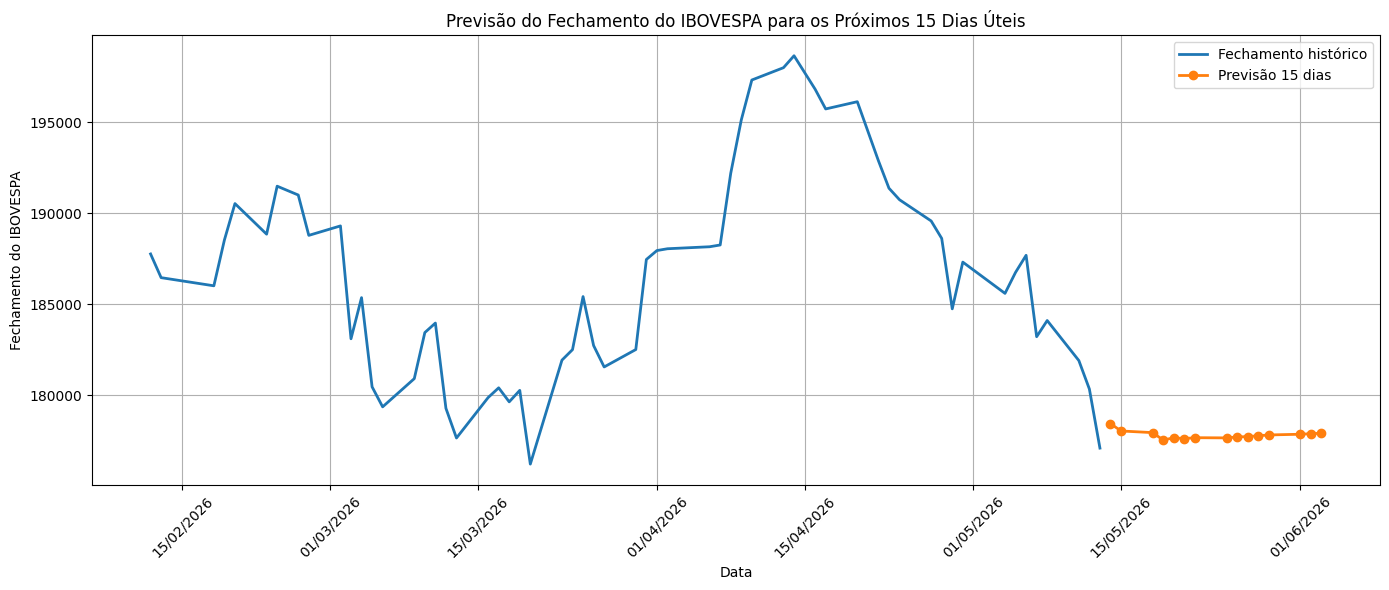

In [219]:
#####################################################################
# BLOCO 34 — VISUALIZAÇÃO DA PREVISÃO FUTURA
# PREDIÇÃO DOS PRÓXIMOS 15 DIAS
#####################################################################

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))

# Últimos 60 pregões históricos
serie_historica_recente = df_ibovespa_idx['fechamento'].tail(60)

# Série histórica recente
plt.plot(
    serie_historica_recente.index,
    serie_historica_recente.values,
    label='Fechamento histórico',
    linewidth=2
)

# Previsão dos próximos 15 dias
plt.plot(
    df_previsao_15_dias['data'],
    df_previsao_15_dias['fechamento_previsto'],
    label='Previsão 15 dias',
    marker='o',
    linewidth=2
)

plt.title('Previsão do Fechamento do IBOVESPA para os Próximos 15 Dias Úteis')
plt.xlabel('Data')
plt.ylabel('Fechamento do IBOVESPA')

# Ajusta formato da data no eixo X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

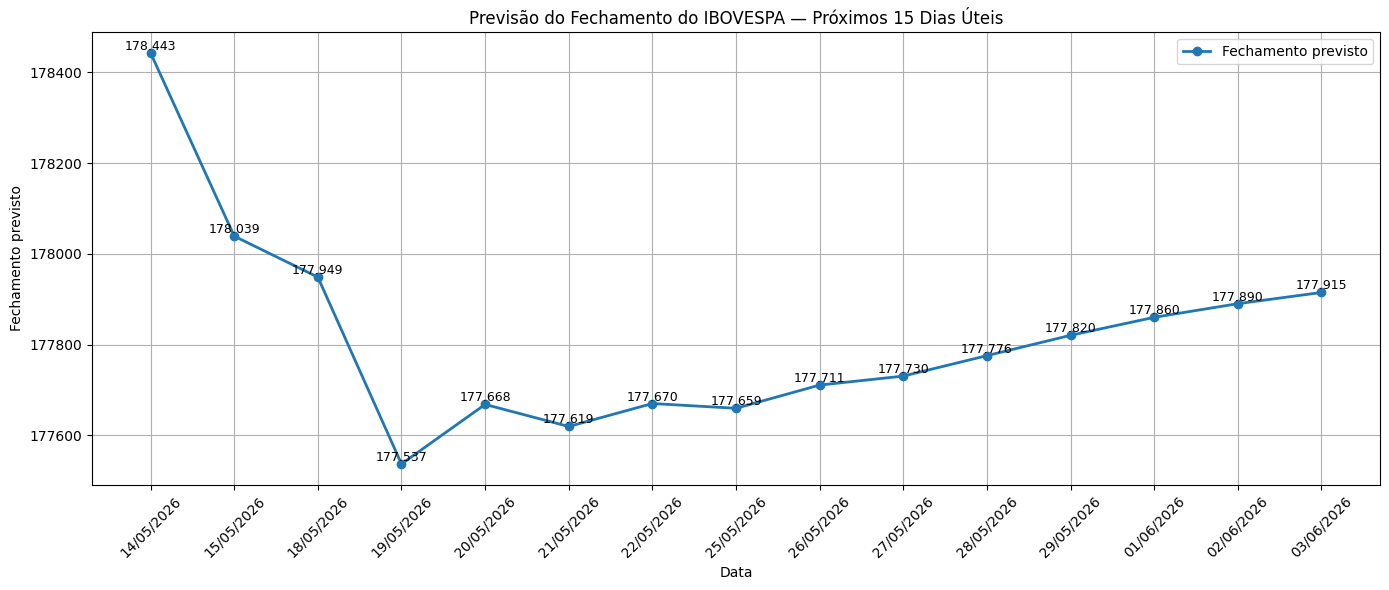

In [220]:
#####################################################################
# BLOCO 34.1 — GRÁFICO DA PREVISÃO DOS 15 DIAS
# PREDIÇÃO DOS PRÓXIMOS 15 DIAS
#####################################################################

import matplotlib.pyplot as plt

# Cria coluna de data formatada para o eixo X
df_previsao_grafico = df_previsao_15_dias.copy()
df_previsao_grafico['data_formatada'] = df_previsao_grafico['data'].dt.strftime('%d/%m/%Y')

plt.figure(figsize=(14, 6))

plt.plot(
    df_previsao_grafico['data_formatada'],
    df_previsao_grafico['fechamento_previsto'],
    marker='o',
    linewidth=2,
    label='Fechamento previsto'
)

# Adiciona o valor previsto em cada ponto
for i, row in df_previsao_grafico.iterrows():
    plt.text(
        row['data_formatada'],
        row['fechamento_previsto'],
        f"{row['fechamento_previsto']:,.0f}".replace(",", "."),
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.title('Previsão do Fechamento do IBOVESPA — Próximos 15 Dias Úteis')
plt.xlabel('Data')
plt.ylabel('Fechamento previsto')

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### **Análise - Previsão dos próximos 15 dias**

O gráfico apresenta exclusivamente a previsão do fechamento do IBOVESPA para os próximos **15 dias úteis**.

As projeções indicam uma leve oscilação inicial, seguida de estabilização dos valores previstos ao longo do período. Os fechamentos estimados permanecem próximos da faixa de **177 mil a 178 mil pontos**.

Essa visualização resume o resultado final do modelo, atendendo ao requisito da prova de apresentar a predição dos próximos 15 dias.

---
---
---
---
---


## **CONCLUSÃO TÉCNICA**

### **Conclusão da modelagem e previsão**


Este trabalho desenvolveu uma estratégia completa para análise e previsão do fechamento diário do IBOVESPA, conforme solicitado na prova substitutiva.

A seguir, são apresentadas as principais etapas realizadas no notebook.

---

### **Etapa 1** — Importação dos dados

Na primeira etapa, foi realizada a importação da base histórica do IBOVESPA a partir do arquivo CSV.

A base contém informações diárias do índice, como data, fechamento, abertura, máxima, mínima, volume negociado e variação percentual.

Essa etapa foi necessária para carregar os dados brutos que seriam usados em todo o processo de análise e modelagem.

---

### **Etapa 2** — Padronização e tratamento da base

Depois da importação, os nomes das colunas foram padronizados para facilitar o uso no Python.

Também foram realizados os principais tratamentos da base:

- conversão da coluna de data para o formato correto;
- ordenação cronológica dos registros;
- conversão da variação percentual para formato numérico;
- conversão do volume negociado para formato numérico;
- verificação de valores nulos;
- checagem da estrutura final da base.

Essa etapa garantiu que os dados estivessem organizados e prontos para a análise temporal.

---

### **Etapa 3** — Análise exploratória dos dados

Na terceira etapa, foi realizada a análise exploratória da série histórica.

Foram analisados:

- evolução do fechamento do IBOVESPA ao longo do tempo;
- média móvel e dispersão do fechamento;
- retornos diários;
- volatilidade dos retornos;
- distribuição dos retornos;
- identificação de valores extremos.

Essa etapa ajudou a entender o comportamento do índice e a identificar períodos de maior estabilidade ou instabilidade.

---

### **Etapa 4** — Análise dos picos de alta e baixa

Em seguida, foram identificados os principais picos de alta e baixa do IBOVESPA no período analisado.

A maior alta diária encontrada foi de **4,29%**, em **11/04/2023**.

A maior baixa diária encontrada foi de **-4,31%**, em **05/12/2025**.

Essa análise atendeu ao requisito da prova de apresentar o contexto dos picos de alta e baixa da série.

---

### **Etapa 5** — Decomposição da série temporal

A série de fechamento do IBOVESPA foi decomposta em três componentes:

- tendência;
- sazonalidade;
- resíduo.

A decomposição mostrou que a série apresentou tendência de crescimento ao longo do período analisado, especialmente a partir de 2025.

Também foram observadas oscilações periódicas e resíduos, que representam movimentos não explicados diretamente pela tendência ou pela sazonalidade.

Essa etapa atendeu ao requisito da prova relacionado à análise de decomposição da série temporal.

---

### **Etapa 6** — Engenharia de atributos temporais

Na etapa seguinte, foram criadas variáveis temporais para preparar a base para a modelagem.

Foram criadas variáveis como:

- retornos passados;
- defasagens do fechamento;
- médias móveis;
- volatilidades;
- amplitude diária;
- variação entre abertura e fechamento.

Essas variáveis permitiram que os modelos usassem informações históricas da série para tentar prever o fechamento do próximo pregão.

---

### **Etapa 7** — Definição da variável alvo

A variável alvo principal foi definida como o **fechamento do próximo pregão**.

Essa escolha está alinhada ao objetivo da prova substitutiva, que pede a previsão diária dos dados de fechamento do IBOVESPA.

Também foi criada uma variável complementar para avaliar a direção do mercado, indicando se o fechamento seguinte seria maior ou menor que o fechamento atual.

Essa variável foi usada apenas como apoio para avaliar a assertividade direcional.

---

### **Etapa 8** — Separação entre treino e teste

A base foi separada em treino e teste respeitando a ordem cronológica dos dados.

Essa decisão é importante porque, em séries temporais, não se deve embaralhar os registros. O modelo precisa aprender com o passado para ser avaliado em um período futuro.

Foram usados **645 registros para treino** e **162 registros para teste**.

---

### **Etapa 9** — Treinamento e comparação dos modelos

Foram testados os seguintes modelos:

- Baseline;
- Regressão Linear;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- KNN Regressor;
- SVR.

O **Baseline** apresentou o menor erro médio, com **MAE de 1.466,66 pontos**, mas não foi considerado como modelo final porque não é um modelo treinado. Ele apenas repete o fechamento atual como previsão do próximo pregão.

Entre os modelos efetivamente treinados, a **Regressão Linear** apresentou o melhor desempenho, com **MAE de 1.564,80 pontos**, **RMSE de 2.082,37** e **R² de 0,9858**.

Por esse motivo, a Regressão Linear foi escolhida como modelo final treinado.

---

### **Etapa 10** — Ajuste do modelo para previsão futura

Antes de prever os próximos 15 dias, o modelo foi ajustado para usar apenas variáveis que podem ser recalculadas no futuro a partir do próprio histórico de fechamento.

Esse ajuste foi necessário porque variáveis como abertura, máxima, mínima e volume não são conhecidas antecipadamente para datas futuras.

Na versão ajustada para previsão futura, a Regressão Linear obteve **MAE de 1.570,57 pontos**, resultado muito próximo ao desempenho anterior.

---

### **Etapa 11** — Predição dos próximos 15 dias

Com o modelo final ajustado, foi realizada a previsão do fechamento do IBOVESPA para os próximos **15 dias úteis**.

As previsões indicaram valores próximos da faixa de **177 mil a 178 mil pontos**, com pequenas oscilações ao longo do período projetado.

Essa etapa atendeu ao requisito da prova de apresentar a predição dos próximos 15 dias.

---

### **Etapa 12** — Limitação sobre a assertividade

O enunciado da prova menciona uma **assertividade mínima de 80%**.

Neste trabalho, **essa meta não foi alcançada** quando interpretada como acerto da direção do mercado, ou seja, prever se o índice subiria ou cairia no próximo pregão.

A acurácia direcional dos modelos ficou abaixo de 50%, indicando que os modelos não foram eficientes para antecipar a direção diária de alta ou baixa.

Esse resultado precisa ser interpretado com cautela. Em séries financeiras, atingir 80% de acerto direcional diário significaria prever corretamente o comportamento do IBOVESPA em 8 de cada 10 pregões. Na prática, esse nível de acerto é extremamente difícil, pois o mercado é influenciado por diversos fatores externos, como cenário econômico, decisões políticas, juros, câmbio, notícias internacionais, guerras, fluxo de investidores e eventos inesperados.

Por esse motivo, a assertividade direcional foi tratada como uma métrica complementar. O foco principal da prova substitutiva é prever o valor de fechamento do IBOVESPA, e essa avaliação foi feita com métricas de regressão, especialmente o **MAE**, que mede o erro médio da previsão em pontos do índice.

Assim, o modelo não atingiu a meta de 80% quando avaliado pela direção de alta ou baixa, mas apresentou uma previsão numérica do fechamento com erro médio mensurado e tecnicamente interpretável.


---

### **Síntese final**

Foram realizadas a importação e preparação dos dados, a análise exploratória, a identificação dos picos de alta e baixa, a decomposição da série temporal, a criação das variáveis temporais, o treinamento e comparação dos modelos, a escolha do modelo final e a previsão dos próximos 15 dias úteis.

A **Regressão Linear** foi escolhida como modelo final por apresentar o melhor desempenho entre os modelos treinados.

As previsões devem ser interpretadas como estimativas estatísticas baseadas no comportamento histórico da série. Elas não representam garantia de comportamento futuro do mercado, pois o IBOVESPA também é influenciado por fatores econômicos, políticos e externos que não estão diretamente presentes na base analisada.